# NB1 -- Pangenome Architecture & Closure

**FunPan Aspergillus Pangenome Project -- Results 3.1**

This notebook constructs pangenome matrices (PAV/CNV), classifies orthogroups into core/accessory/rare,
tests pangenome openness via Heap's law, loads functional annotations, performs functional enrichment
of pangenome classes, computes SNP PCA/GRM, and builds BGC/GCF matrices.

All outputs are saved under `NB1_Results/`.

---
## Section 1: Configuration

In [2]:
import sys, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
import funpan_pangenome as fpp

GENUS = 'Aspergillus'
SPECIES_LIST = fpu.SPECIES_LIST
RESULTS_BASE = '/datadrive/Analysis/NB1_Results'
SPECIES_ROOT = '/datadrive/Species/Aspergillus'

# Create output directories
for sp in SPECIES_LIST:
    os.makedirs(os.path.join(RESULTS_BASE, sp), exist_ok=True)

print(f'Species: {SPECIES_LIST}')
print(f'Results base: {RESULTS_BASE}')

Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Results base: /datadrive/Analysis/NB1_Results


In [3]:
# Load phenotype labels produced by NB0
pheno_df = pd.read_csv('/datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv')
print(f'Phenotype table: {pheno_df.shape}')
pheno_df.head()

Phenotype table: (207, 69)


,Assembly Accession,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
0,GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
1,GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
2,GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
3,GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
4,GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


---
## Section 2: Load OrthoFinder Results & Build PAV / CNV Matrices

In [4]:
# Load OrthoFinder results and build PAV/CNV matrices (fpp.load_all_orthofinder)
ortho_data, pav_data, cnv_data = fpp.load_all_orthofinder(SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE)


=== fumigatus ===
  Loaded cached PAV ((10951, 89)) and CNV ((10951, 89)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae


---
## Section 3: Pangenome Classification (Core / Accessory / Rare)


=== fumigatus ===
  Loaded cached classification (837,154 OGs)
  Class counts:
Pangenome_Class
Core         748234
Accessory     85938
Rare           2982


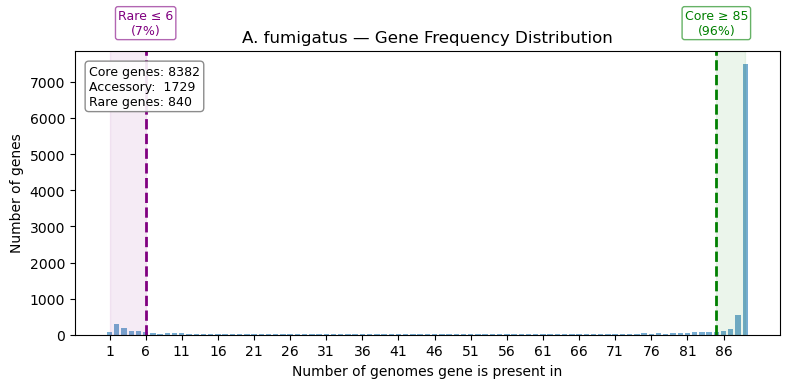


=== flavus ===
  Loaded cached classification (875,014 OGs)
  Class counts:
Pangenome_Class
Core         766141
Accessory    104463
Rare           4410


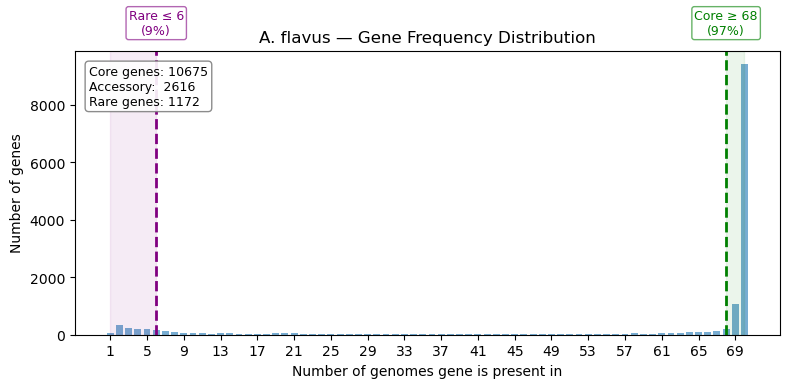


=== niger ===
  Loaded cached classification (209,403 OGs)
  Class counts:
Pangenome_Class
Core         180856
Accessory     27325
Rare           1222


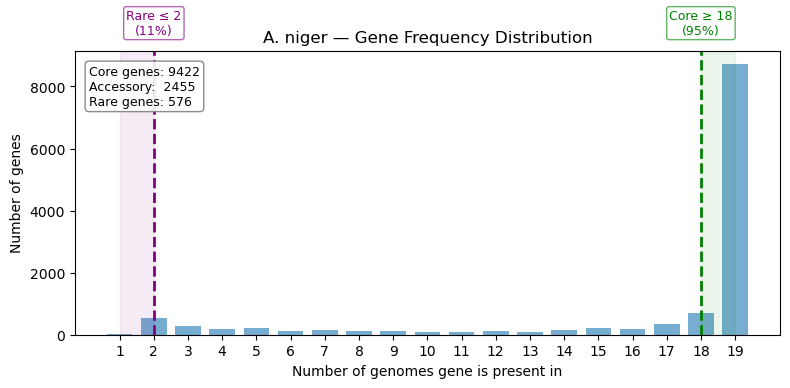


=== oryzae ===
  Loaded cached classification (416,657 OGs)
  Class counts:
Pangenome_Class
Core         368679
Accessory     46641
Rare           1337


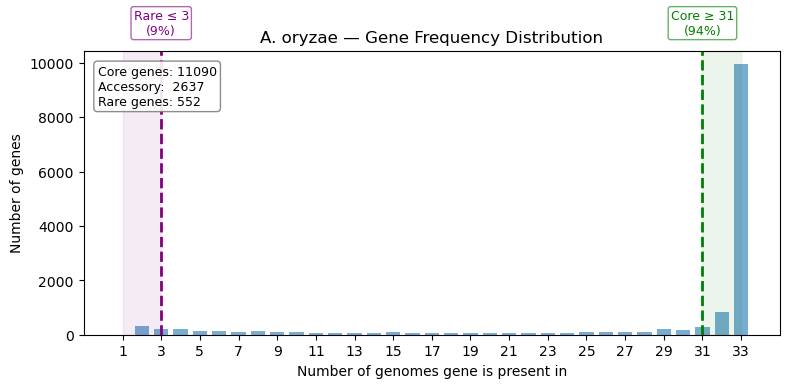

In [5]:
# Classify orthogroups into Core/Accessory/Rare (fpp.classify_all_pangenomes)
pangenome_class = fpp.classify_all_pangenomes(SPECIES_LIST, ortho_data, pav_data, RESULTS_BASE)

In [6]:
# Pangenome class comparison across species (fpp.pangenome_class_summary)
summary_df = fpp.pangenome_class_summary(pangenome_class, SPECIES_LIST)
print(summary_df.to_string(index=False))

  Species   Core  Core (%)  Accessory  Accessory (%)  Rare  Rare (%)
fumigatus 748234      89.4      85938           10.3  2982       0.4
   flavus 766141      87.6     104463           11.9  4410       0.5
    niger 180856      86.4      27325           13.0  1222       0.6
   oryzae 368679      88.5      46641           11.2  1337       0.3


In [7]:
# --- Interpretation: Pangenome Classification ---
print('Pangenome Classification Summary')
print('=' * 50)
for sp in SPECIES_LIST:
    if sp not in pangenome_class:
        continue
    cls = pangenome_class[sp]
    pav = pav_data[sp]
    n_genomes = pav.shape[1]
    counts = cls['Pangenome_Class'].value_counts()
    n_total = counts.sum()
    print(f'\nA. {sp} ({n_genomes} genomes, {n_total} orthogroups):')
    for cat in ['Core', 'Accessory', 'Rare']:
        n = counts.get(cat, 0)
        pct = 100 * n / n_total
        print(f'  {cat}: {n:,} ({pct:.1f}%)')


Pangenome Classification Summary

A. fumigatus (89 genomes, 837154 orthogroups):
  Core: 748,234 (89.4%)
  Accessory: 85,938 (10.3%)
  Rare: 2,982 (0.4%)

A. flavus (70 genomes, 875014 orthogroups):
  Core: 766,141 (87.6%)
  Accessory: 104,463 (11.9%)
  Rare: 4,410 (0.5%)

A. niger (19 genomes, 209403 orthogroups):
  Core: 180,856 (86.4%)
  Accessory: 27,325 (13.0%)
  Rare: 1,222 (0.6%)

A. oryzae (33 genomes, 416657 orthogroups):
  Core: 368,679 (88.5%)
  Accessory: 46,641 (11.2%)
  Rare: 1,337 (0.3%)


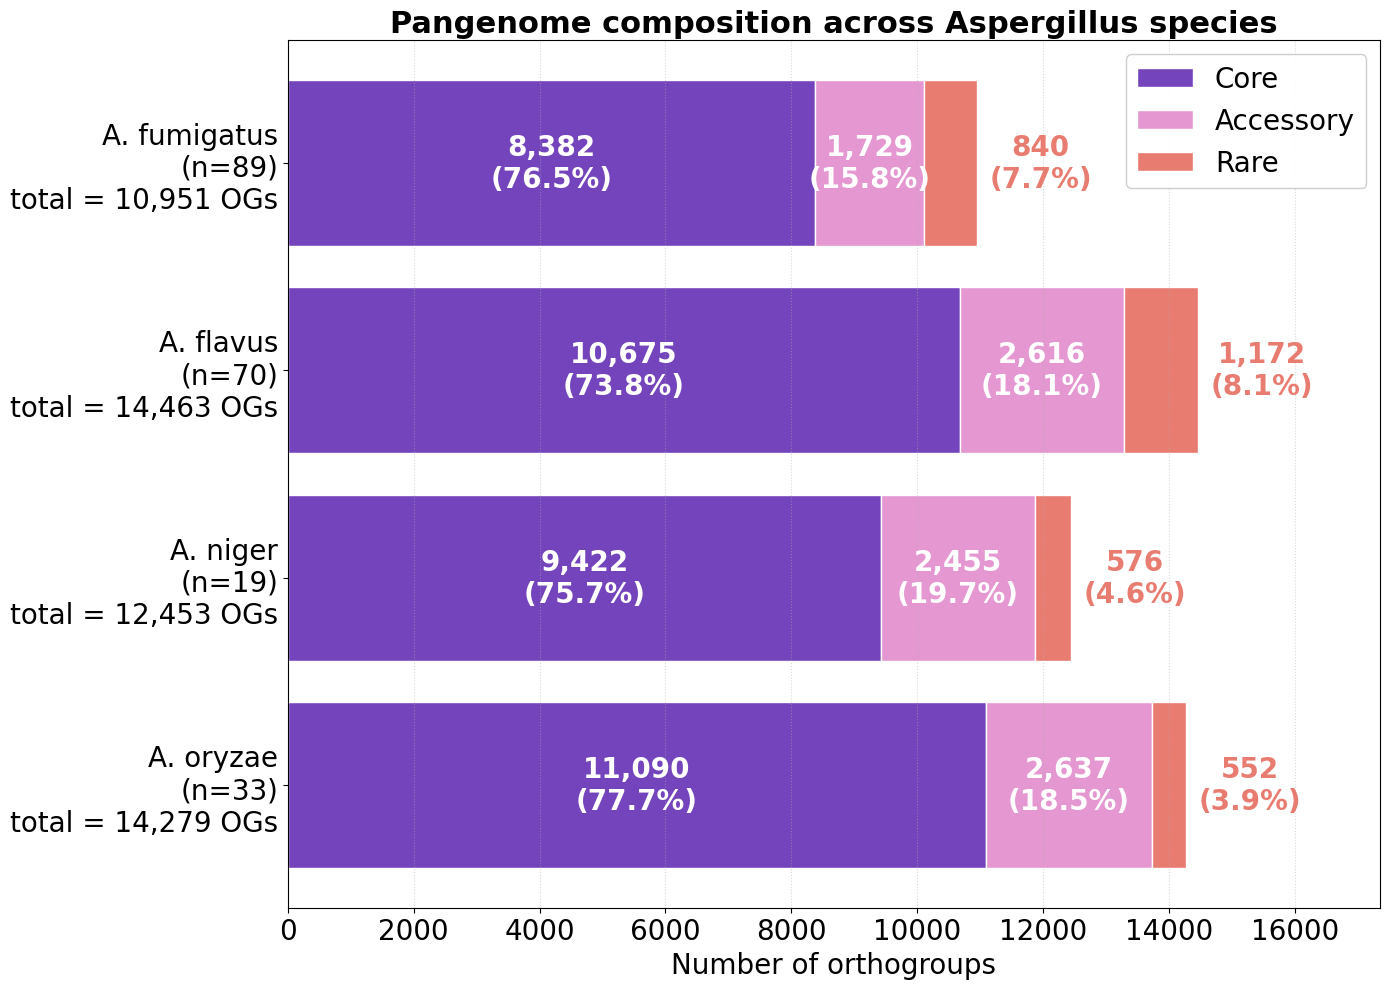

Saved -> /datadrive/Analysis/NB1_Results/pangenome_composition_combined.png  (+ .pdf)

Per-species per-OG counts:
  A. fumigatus: Core=8,382  Accessory=1,729  Rare=840  Total=10,951
  A. flavus: Core=10,675  Accessory=2,616  Rare=1,172  Total=14,463
  A. niger: Core=9,422  Accessory=2,455  Rare=576  Total=12,453
  A. oryzae: Core=11,090  Accessory=2,637  Rare=552  Total=14,279


In [13]:
# --- Compact figure: pangenome composition (absolute counts with % labels) ---
# pangenome_class[sp] is the long per-protein table — dedup by Orthogroup
# to get per-OG counts (matching Figure_1 panel e).
core_n, acc_n, rare_n, n_genomes_list = [], [], [], []
for sp in SPECIES_LIST:
    per_og = pangenome_class[sp].drop_duplicates('Orthogroup')
    counts = per_og['Pangenome_Class'].value_counts()
    core_n.append(int(counts.get('Core', 0)))
    acc_n.append(int(counts.get('Accessory', 0)))
    rare_n.append(int(counts.get('Rare', 0)))
    n_genomes_list.append(pav_data[sp].shape[1])

totals = [c + a + r for c, a, r in zip(core_n, acc_n, rare_n)]
core_pcts = [100 * c / t for c, t in zip(core_n, totals)]
acc_pcts  = [100 * a / t for a, t in zip(acc_n, totals)]
rare_pcts = [100 * r / t for r, t in zip(rare_n, totals)]

# Total OG count moved into the y-axis label, under the n=
labels = [f"A. {sp}\n(n={n})\ntotal = {t:,} OGs"
          for sp, n, t in zip(SPECIES_LIST, n_genomes_list, totals)]
y = np.arange(len(SPECIES_LIST))
core_c, acc_c, rare_c = "#7444BC", "#e497d0", "#e97c70"

FS = 20
fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(y, core_n, color=core_c, edgecolor='white', label='Core')
ax.barh(y, acc_n,  left=core_n, color=acc_c,  edgecolor='white', label='Accessory')
ax.barh(y, rare_n, left=[c+a for c,a in zip(core_n, acc_n)],
        color=rare_c, edgecolor='white', label='Rare')

xmax = max(totals)
for i, (c, a, r, t, cp, ap, rp) in enumerate(zip(core_n, acc_n, rare_n, totals,
                                                 core_pcts, acc_pcts, rare_pcts)):
    ax.text(c/2, i, f'{c:,}\n({cp:.1f}%)', ha='center', va='center',
            fontsize=FS, color='white', fontweight='bold')
    ax.text(c + a/2, i, f'{a:,}\n({ap:.1f}%)', ha='center', va='center',
            fontsize=FS, color='white', fontweight='bold')
    # Rare segment too narrow for inside text — annotate just outside the bar end
    ax.text(t + xmax*0.07, i, f'{r:,}\n({rp:.1f}%)',
            ha='center', va='center', fontsize=FS, color=rare_c, fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=FS)
ax.tick_params(axis='x', labelsize=FS)
ax.set_xlabel('Number of orthogroups', fontsize=FS)
ax.set_xlim(0, xmax * 1.20); ax.invert_yaxis()
ax.set_title('Pangenome composition across Aspergillus species',
             fontweight='bold', fontsize=FS + 2)
ax.legend(loc='upper right', fontsize=FS, frameon=True, framealpha=0.95)
ax.grid(True, axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_BASE, 'pangenome_composition_combined.png'),
            dpi=800, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_BASE, 'pangenome_composition_combined.pdf'),
            bbox_inches='tight')
plt.show()
print(f"Saved -> {RESULTS_BASE}/pangenome_composition_combined.png  (+ .pdf)")
print()
print('Per-species per-OG counts:')
for sp, c, a, r, t in zip(SPECIES_LIST, core_n, acc_n, rare_n, totals):
    print(f"  A. {sp}: Core={c:,}  Accessory={a:,}  Rare={r:,}  Total={t:,}")


---
## Section 4: Heap's Law / Pangenome Openness

  fumigatus: loaded cached Heaps' law results (γ = 0.033, CLOSED)
  flavus: loaded cached Heaps' law results (γ = 0.038, CLOSED)
  niger: loaded cached Heaps' law results (γ = 0.048, CLOSED)
  oryzae: loaded cached Heaps' law results (γ = 0.035, CLOSED)


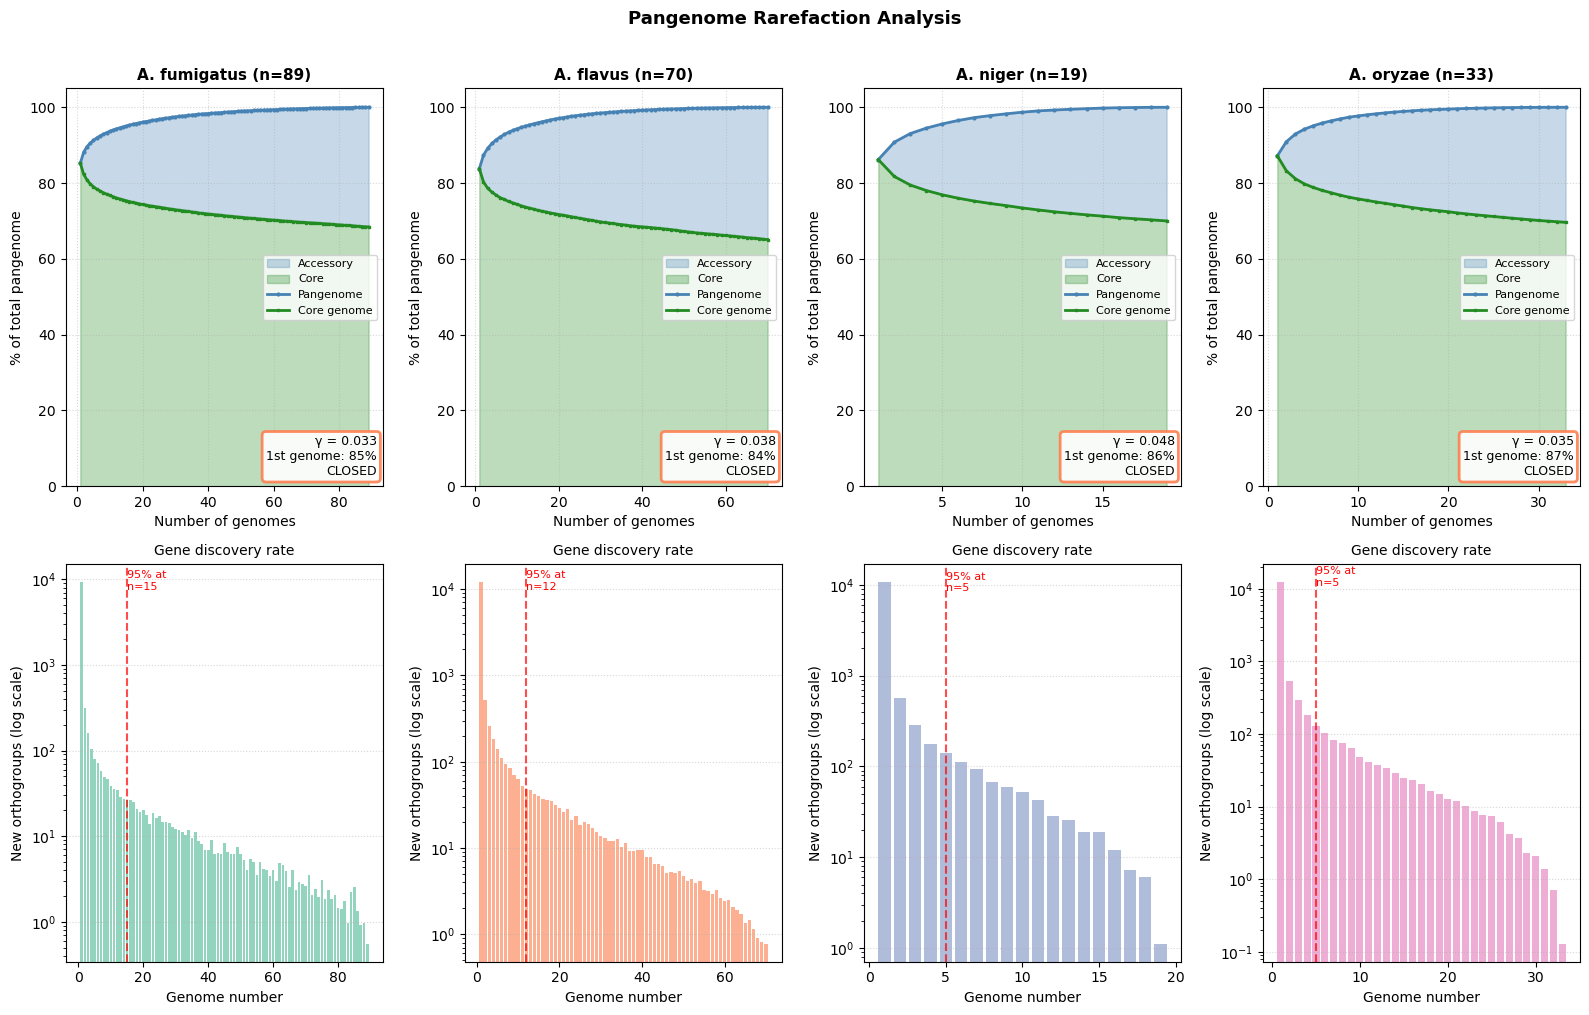

In [9]:
# Heap's law analysis — caches per-species results to NB1_Results/{sp}/{sp}_heaps.pkl
# Pass force=True to rerun the bootstrap
orthofinder_data_dict = {sp: {'pav': pav_data[sp]} for sp in SPECIES_LIST if sp in pav_data}
heaps_results, _ = fpp.analyze_heaps_law(orthofinder_data_dict, SPECIES_LIST, n_boot=200, results_base=RESULTS_BASE)


In [10]:
# --- Interpretation: Heap's Law Results ---
print('Pangenome Openness (Heap\'s Law)')
print('=' * 50)
print('gamma < 0.05 indicates a closed pangenome.\n')
if 'heaps_results' in dir():
    for sp, res in heaps_results.items():
        gamma = res.get('gamma', None)
        if gamma is not None:
            status = 'CLOSED' if gamma < 0.05 else 'OPEN'
            print(f'  A. {sp}: gamma = {gamma:.4f} ({status})')
else:
    print('  (Run Heap\'s law analysis cell above first)')


Pangenome Openness (Heap's Law)
gamma < 0.05 indicates a closed pangenome.

  A. fumigatus: gamma = 0.0335 (CLOSED)
  A. flavus: gamma = 0.0377 (CLOSED)
  A. niger: gamma = 0.0480 (CLOSED)
  A. oryzae: gamma = 0.0353 (CLOSED)


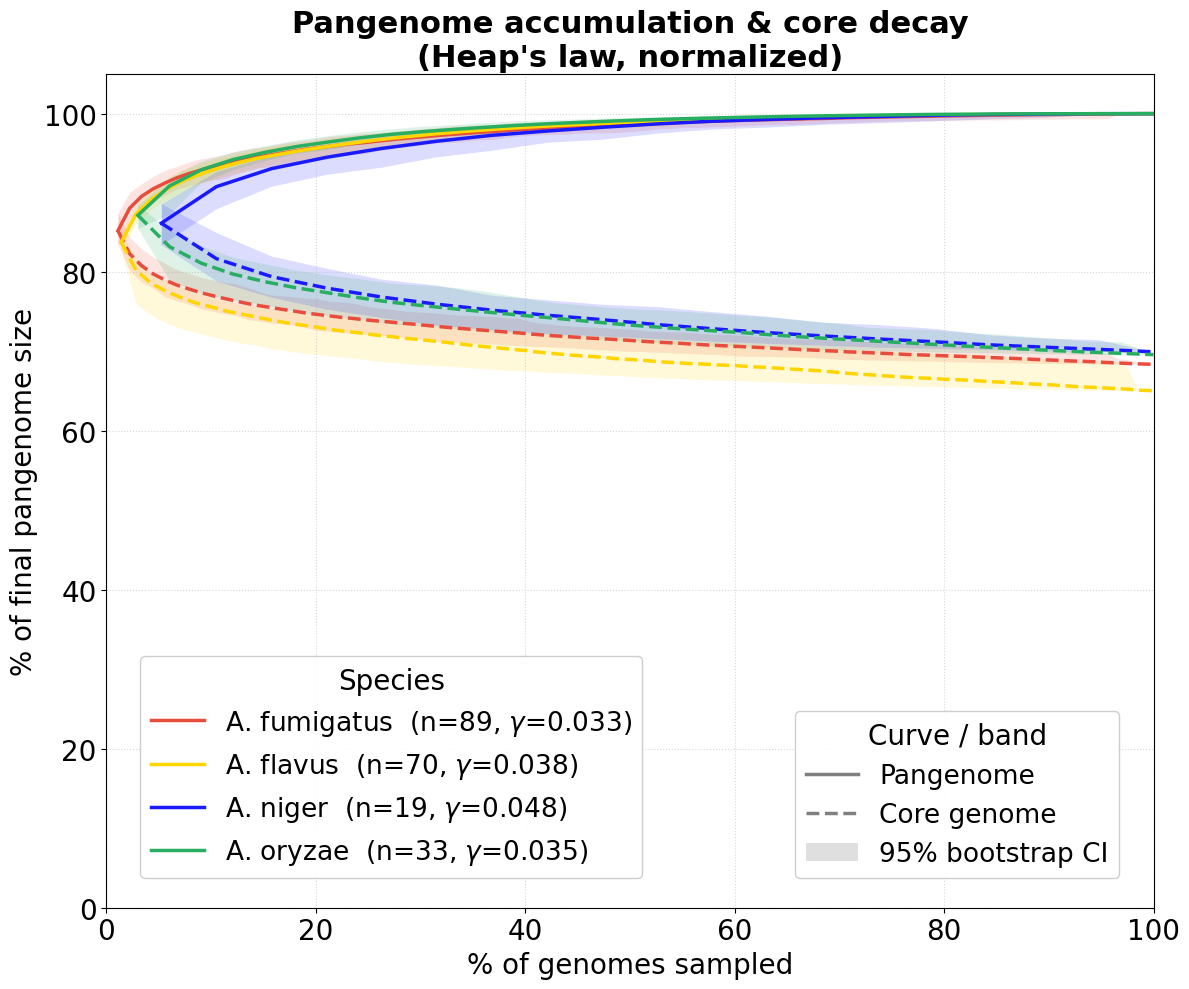

Saved -> /datadrive/Analysis/NB1_Results/heaps_law_combined.png  (+ .pdf)


In [11]:
# --- Compact figure: Heap's law — normalized pangenome accumulation & core decay ---
import pickle
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FS = 20
fig, ax = plt.subplots(figsize=(12, 10))
# Use the same per-species color palette as the geographic distribution / world
# map figure in NB0 (funpan_utils.SPECIES_COLORS), so species colors are
# consistent across all figures in the paper.
colors = {sp: fpu.SPECIES_COLORS.get(sp, '#333333') for sp in SPECIES_LIST}
species_handles = []

for sp in SPECIES_LIST:
    with open(os.path.join(RESULTS_BASE, sp, f'{sp}_heaps.pkl'), 'rb') as f:
        h = pickle.load(f)
    n = h['n_genomes']
    Ns_pct = 100 * np.arange(1, n + 1) / n
    c = colors[sp]
    gamma = h['gamma']

    pan = np.asarray(h['pangenome_size']); core = np.asarray(h['core_size'])
    pan_lo, pan_hi = np.asarray(h['pan_ci_lo']), np.asarray(h['pan_ci_hi'])
    core_lo, core_hi = np.asarray(h['core_ci_lo']), np.asarray(h['core_ci_hi'])
    pan_final = pan[-1]

    ax.fill_between(Ns_pct, 100*pan_lo/pan_final, 100*pan_hi/pan_final,
                    color=c, alpha=0.15, linewidth=0)
    ax.fill_between(Ns_pct, 100*core_lo/pan_final, 100*core_hi/pan_final,
                    color=c, alpha=0.15, linewidth=0)
    ax.plot(Ns_pct, 100*pan/pan_final,  '-',  color=c, linewidth=2.5)
    ax.plot(Ns_pct, 100*core/pan_final, '--', color=c, linewidth=2.5)

    species_handles.append(Line2D([0],[0], color=c, lw=2.5,
                                  label=f"A. {sp}  (n={n}, $\\gamma$={gamma:.3f})"))

ax.set_xlabel('% of genomes sampled', fontsize=FS)
ax.set_ylabel('% of final pangenome size', fontsize=FS)
ax.set_title("Pangenome accumulation & core decay\n(Heap's law, normalized)",
             fontweight='bold', fontsize=FS + 2)
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
ax.tick_params(axis='both', labelsize=FS)
ax.grid(True, linestyle=':', alpha=0.5)

# Two non-overlapping legends, both inside the axes.
# The "Curve" legend now also explains the shaded band (95% bootstrap CI).
style_handles = [
    Line2D([0],[0], color='gray', lw=2.5, linestyle='-',  label='Pangenome'),
    Line2D([0],[0], color='gray', lw=2.5, linestyle='--', label='Core genome'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='none',
          label='95% bootstrap CI'),
]
leg1 = ax.legend(handles=species_handles, loc='lower left',
                 bbox_to_anchor=(0.02, 0.02),
                 fontsize=FS - 1, title='Species', title_fontsize=FS,
                 frameon=True, framealpha=0.95)
ax.add_artist(leg1)
ax.legend(handles=style_handles, loc='lower right',
          bbox_to_anchor=(0.98, 0.02),
          fontsize=FS - 1, title='Curve / band', title_fontsize=FS,
          frameon=True, framealpha=0.95)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_BASE, 'heaps_law_combined.png'),
            dpi=800, bbox_inches='tight')
fig.savefig(os.path.join(RESULTS_BASE, 'heaps_law_combined.pdf'),
            bbox_inches='tight')
plt.show()
print(f"Saved -> {RESULTS_BASE}/heaps_law_combined.png  (+ .pdf)")


---
## Section 5: Functional Annotation Loading

In [9]:
# Load annotations and build OG consensus tables (fpp.load_all_annotations_and_consensus)
og_consensus = fpp.load_all_annotations_and_consensus(
    SPECIES_LIST, SPECIES_ROOT, ortho_data, pangenome_class, pav_data, RESULTS_BASE
)


=== fumigatus ===
[i] Found existing /datadrive/Species/Aspergillus/fumigatus/fumigatus_ortho_annot_long.tsv — loading long per-protein table.
  Annotated long table: (837154, 38)
  OG consensus table: (10951, 23)
  Saved -> /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_og_consensus.tsv

=== flavus ===
[i] Found existing /datadrive/Species/Aspergillus/flavus/flavus_ortho_annot_long.tsv — loading long per-protein table.
  Annotated long table: (875014, 38)
  OG consensus table: (14463, 23)
  Saved -> /datadrive/Analysis/NB1_Results/flavus/flavus_og_consensus.tsv

=== niger ===
[i] Found existing /datadrive/Species/Aspergillus/niger/niger_ortho_annot_long.tsv — loading long per-protein table.
  Annotated long table: (209403, 38)
  OG consensus table: (12453, 23)
  Saved -> /datadrive/Analysis/NB1_Results/niger/niger_og_consensus.tsv

=== oryzae ===
[i] Found existing /datadrive/Species/Aspergillus/oryzae/oryzae_ortho_annot_long.tsv — loading long per-protein table.
  Annotated lon

---
## Section 6: Functional Enrichment (Core vs Accessory)


=== fumigatus ===
[OK] COG_category: 84 tests, 16 significant (FDR < 0.05)
[OK] KEGG_TC: 36 tests, 1 significant (FDR < 0.05)
[OK] CAZy: 188 tests, 0 significant (FDR < 0.05)
[OK] dbcan_Substrate: 26 tests, 0 significant (FDR < 0.05)
[OK] GOs: 95 tests, 0 significant (FDR < 0.05)
[OK] PFAMs: 558 tests, 36 significant (FDR < 0.05)
[OK] EC: 122 tests, 1 significant (FDR < 0.05)
[OK] KEGG_ko: 112 tests, 10 significant (FDR < 0.05)
[OK] KEGG_Pathway: 226 tests, 1 significant (FDR < 0.05)
[OK] interpro_IPR: 521 tests, 17 significant (FDR < 0.05)
  Enrichment: 10 annotation layers tested


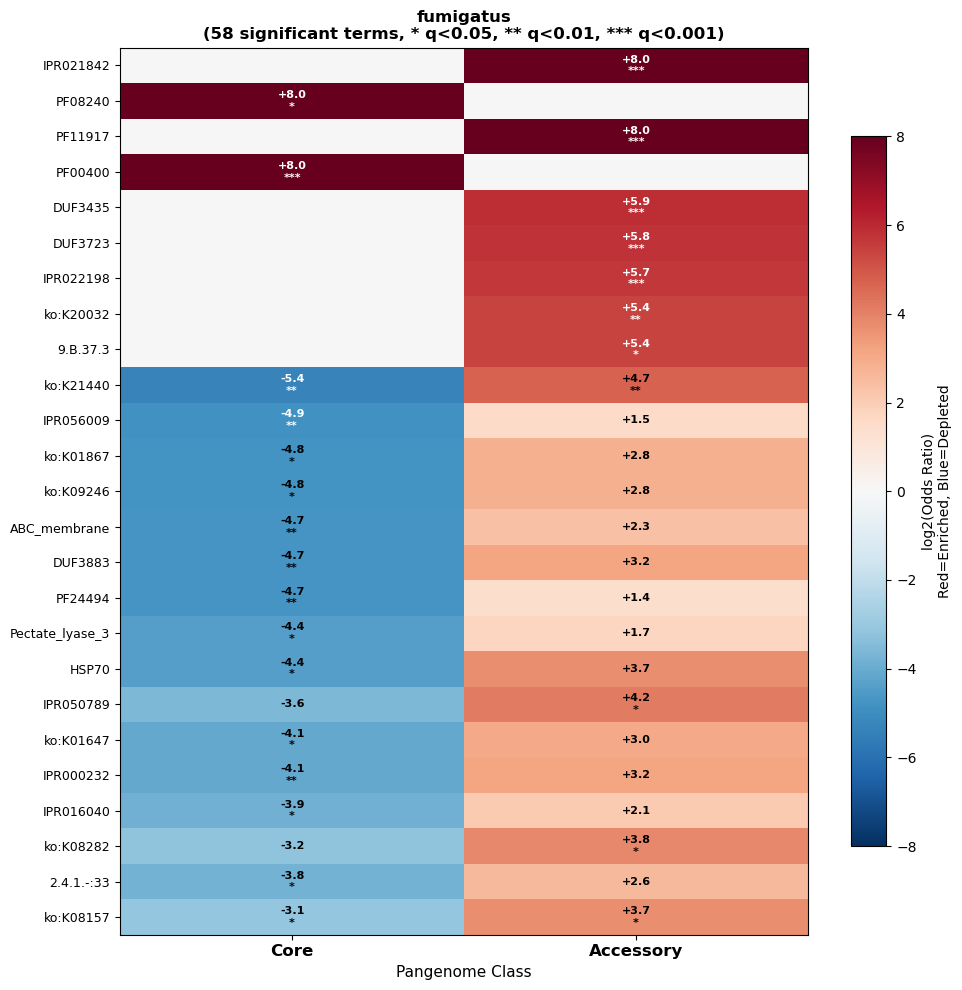

  Species     Category Pangenome_Class  N_Significant                       Top_Terms  Min_q_value  Max_Fold_Enrichment
fumigatus COG_category            Core              9                         S; J; A 3.260204e-10             1.103111
fumigatus COG_category       Accessory              7                         S; J; U 6.777475e-11             3.013659
fumigatus      KEGG_TC       Accessory              1                        9.B.37.3 1.169181e-02             8.506122
fumigatus        PFAMs            Core             22             Zn_clus; MFS_1; APH 2.034410e-10             1.232926
fumigatus        PFAMs       Accessory             14           Zn_clus; DUF3435; APH 2.418384e-08             7.683110
fumigatus           EC            Core              1                      2.4.1.-:33 1.313374e-02             0.351273
fumigatus      KEGG_ko            Core              6 ko:K21440; ko:K01647; ko:K09246 2.970987e-03             0.716530
fumigatus      KEGG_ko       Accessory  

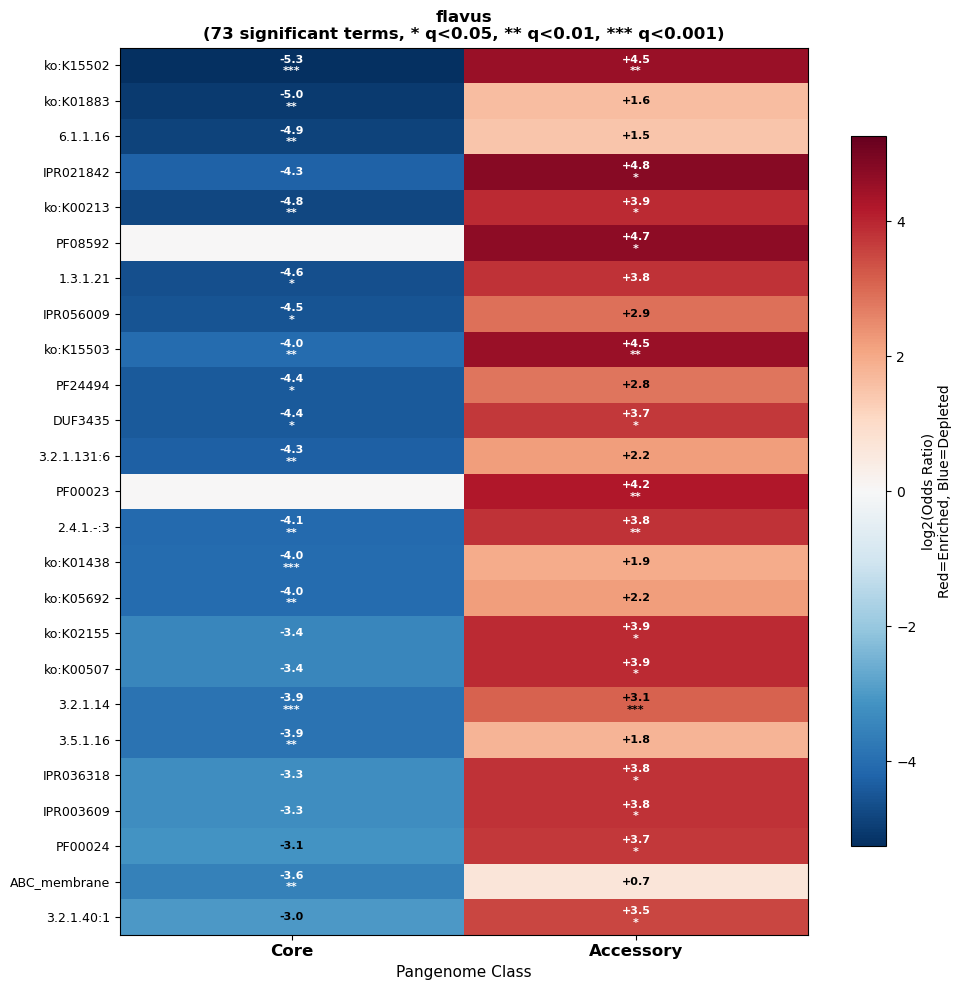

Species     Category Pangenome_Class  N_Significant                       Top_Terms  Min_q_value  Max_Fold_Enrichment
 flavus COG_category            Core              8                         Q; A; J 1.783352e-06             1.152408
 flavus COG_category       Accessory              7                         S; A; Q 3.437212e-06             2.525771
 flavus      KEGG_TC            Core              1                          2.A.17 3.859382e-03             0.609780
 flavus      KEGG_TC       Accessory              1                          2.A.17 1.987122e-03             3.397590
 flavus         CAZy            Core              2                     GH115; GH78 3.056057e-03             0.706308
 flavus         CAZy       Accessory              1                            GH78 3.056057e-03             3.307550
 flavus          GOs       Accessory              1                      GO:0043386 3.477853e-02             5.534818
 flavus        PFAMs            Core             18     

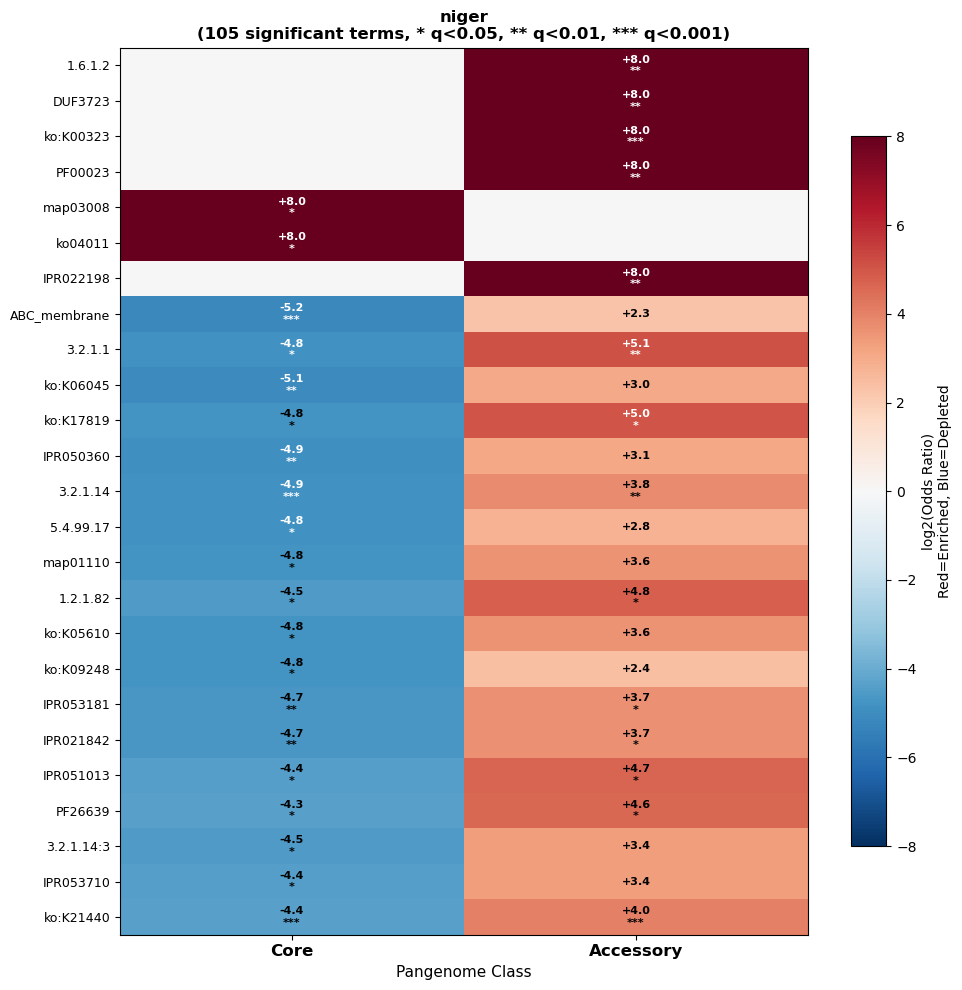

Species        Category Pangenome_Class  N_Significant                          Top_Terms  Min_q_value  Max_Fold_Enrichment
  niger    COG_category            Core             10                            A; S; J 2.718139e-09             1.167241
  niger    COG_category       Accessory              8                            S; A; J 5.425720e-08             1.754045
  niger            CAZy            Core              4                 GH18; CBM50; CBM18 2.518468e-02             0.804456
  niger            CAZy       Accessory              3                 GH18; CBM50; CBM18 2.518468e-02             3.597884
  niger dbcan_Substrate            Core              1                             chitin 3.316332e-04             0.674085
  niger dbcan_Substrate       Accessory              1                             chitin 3.316332e-04             2.735043
  niger             GOs            Core              1                         GO:0045184 1.365286e-03             1.054934
  niger 

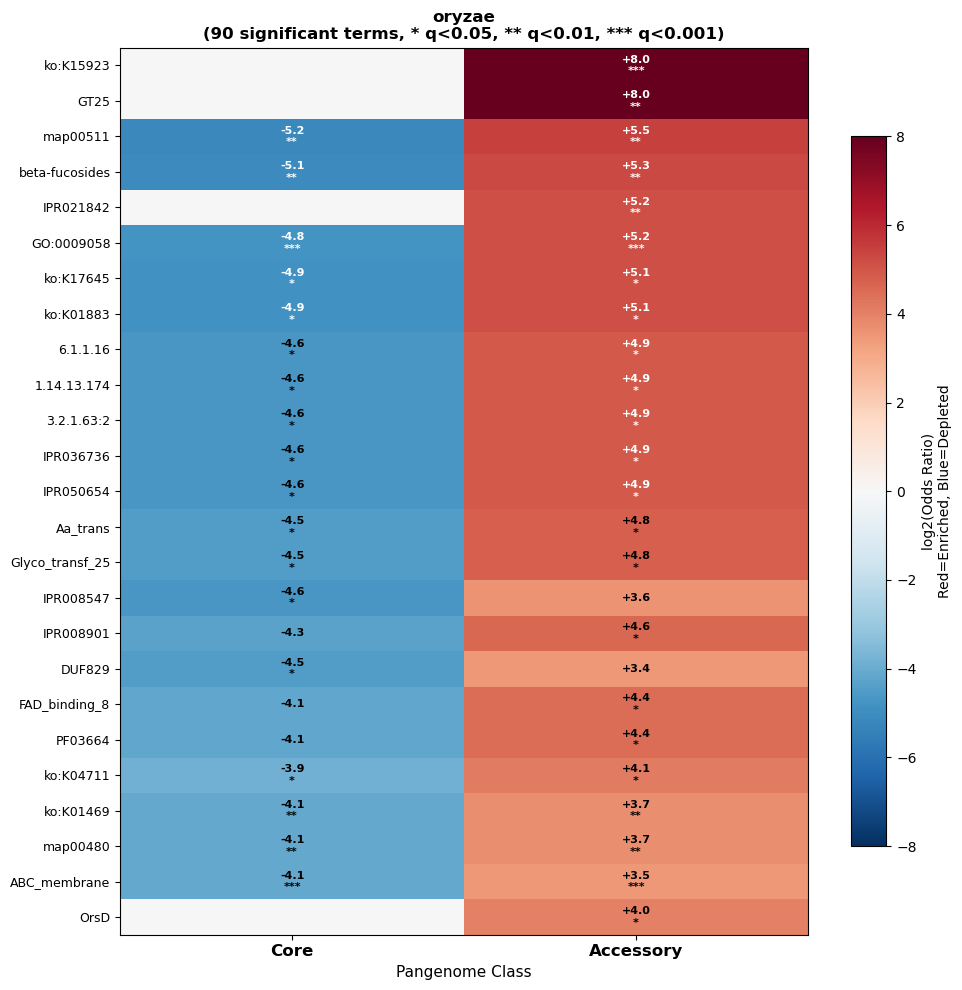

Species        Category Pangenome_Class  N_Significant                        Top_Terms  Min_q_value  Max_Fold_Enrichment
 oryzae    COG_category            Core              8                          Q; A; J 1.630064e-08             1.124598
 oryzae    COG_category       Accessory              7                          Q; U; J 2.443139e-06             1.651291
 oryzae            CAZy            Core              4                GH18; GH92; AA1_3 6.730099e-03             0.825390
 oryzae            CAZy       Accessory              4                 GT25; GH18; GH35 2.026953e-03            10.059701
 oryzae dbcan_Substrate            Core              1                   beta-fucosides 3.773611e-03             0.193074
 oryzae dbcan_Substrate       Accessory              1                   beta-fucosides 3.773611e-03             6.757576
 oryzae             GOs            Core              2           GO:0043386; GO:0009058 9.890428e-04             0.517386
 oryzae             GOs 

In [10]:
# Functional enrichment analysis (fpp.run_all_enrichment)
enrichment_results = fpp.run_all_enrichment(SPECIES_LIST, og_consensus, RESULTS_BASE)

In [11]:
# --- Interpretation: Functional Enrichment ---
print('Functional Enrichment Summary (Core vs Accessory)')
print('=' * 60)
if 'enrichment_results' in dir():
    for sp, enr in enrichment_results.items():
        if not isinstance(enr, dict):
            continue
        for layer, df_enr in enr.items():
            if not hasattr(df_enr, 'query') or 'q_value' not in df_enr.columns:
                continue
            sig = df_enr[df_enr['q_value'] < 0.05]
            if len(sig) > 0:
                print(f'\nA. {sp} | {layer}: {len(sig)} significant terms (FDR < 0.05)')
                top = sig.nsmallest(5, 'q_value')
                for _, row in top.iterrows():
                    term = row.get('Term', '?')
                    odds = row.get('Odds_Ratio', 0)
                    pclass = row.get('Pangenome_Class', '?')
                    direction = row.get('Direction', '')
                    print(f'    [{pclass}] {term}: OR={odds:.2f} ({direction})')
else:
    print('  (Run enrichment cell above first)')


Functional Enrichment Summary (Core vs Accessory)

A. fumigatus | COG_category: 16 significant terms (FDR < 0.05)
    [Accessory] S: OR=1.62 (enriched)
    [Core] S: OR=0.67 (depleted)
    [Core] J: OR=1.96 (enriched)
    [Core] A: OR=2.09 (enriched)
    [Core] O: OR=1.67 (enriched)

A. fumigatus | KEGG_TC: 1 significant terms (FDR < 0.05)
    [Accessory] 9.B.37.3: OR=41.87 (enriched)

A. fumigatus | PFAMs: 36 significant terms (FDR < 0.05)
    [Core] Zn_clus: OR=0.28 (depleted)
    [Core] MFS_1: OR=0.21 (depleted)
    [Accessory] Zn_clus: OR=3.44 (enriched)
    [Core] APH: OR=0.14 (depleted)
    [Accessory] DUF3435: OR=60.60 (enriched)

A. fumigatus | EC: 1 significant terms (FDR < 0.05)
    [Core] 2.4.1.-:33: OR=0.07 (depleted)

A. fumigatus | KEGG_ko: 10 significant terms (FDR < 0.05)
    [Core] ko:K21440: OR=0.02 (depleted)
    [Accessory] ko:K21440: OR=26.89 (enriched)
    [Accessory] ko:K20032: OR=42.92 (enriched)
    [Accessory] ko:K08157: OR=13.44 (enriched)
    [Core] ko:K0164

---
## Section 7: SNP PCA & Kinship / GRM


=== fumigatus ===
Loaded SNP alignment: 89 samples, 153182 SNP sites
SNP matrix: 89 samples x 153182 informative SNPs
PCA computed: 10 components
Variance explained: PC1=44.8%, PC2=6.9%
  SNP PCs saved: (89, 11)
GRM computed: 89 x 89 matrix
GRM saved to: /datadrive/Analysis/NB1_Results/fumigatus/fumigatus_kinship.tsv


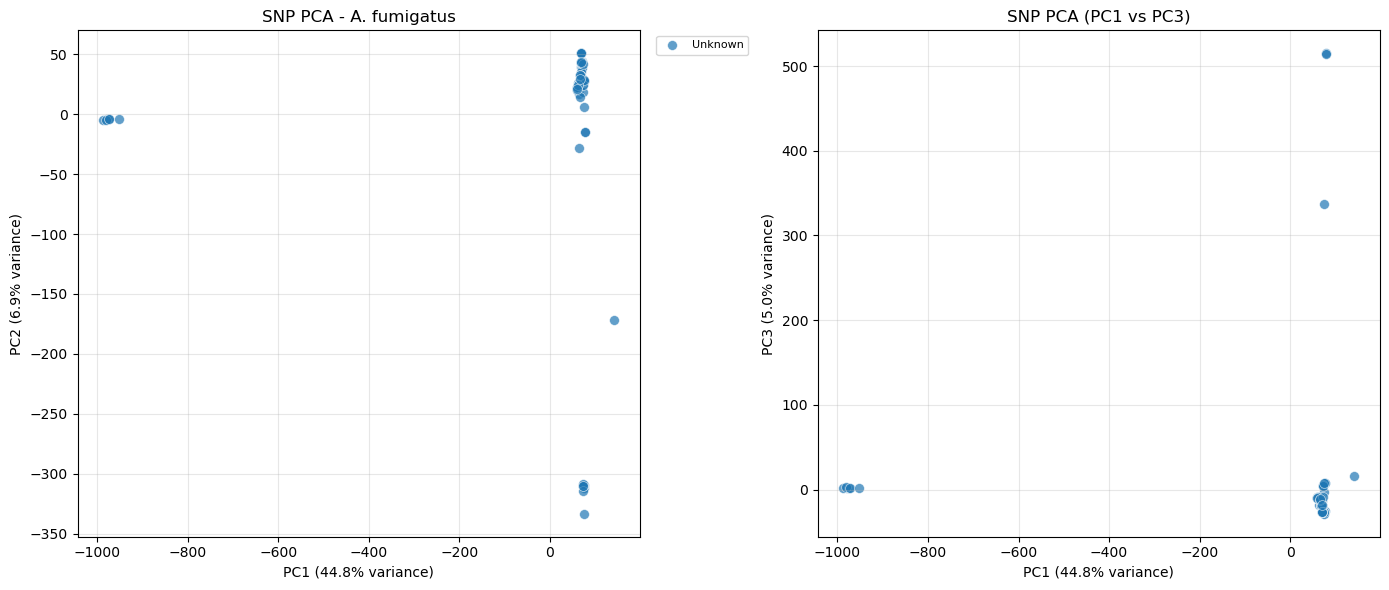

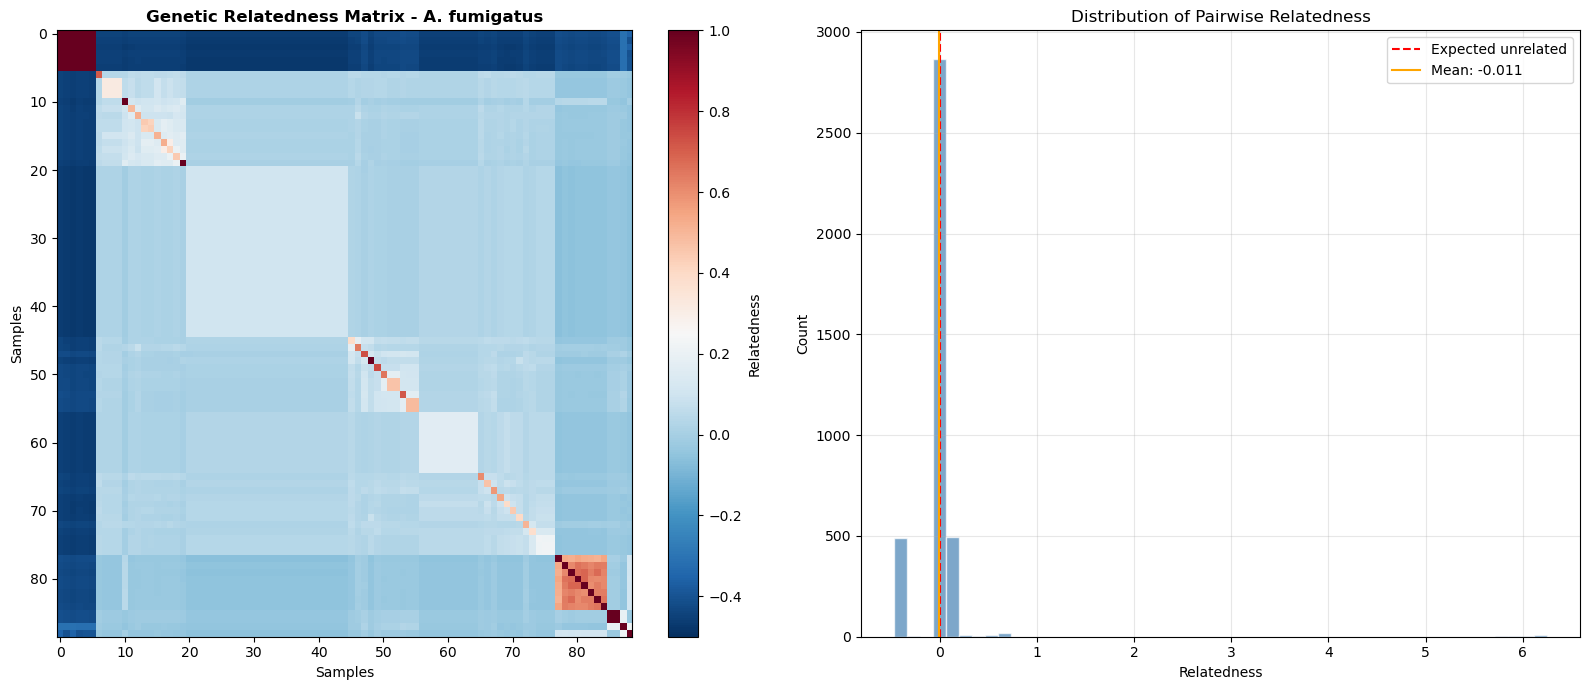

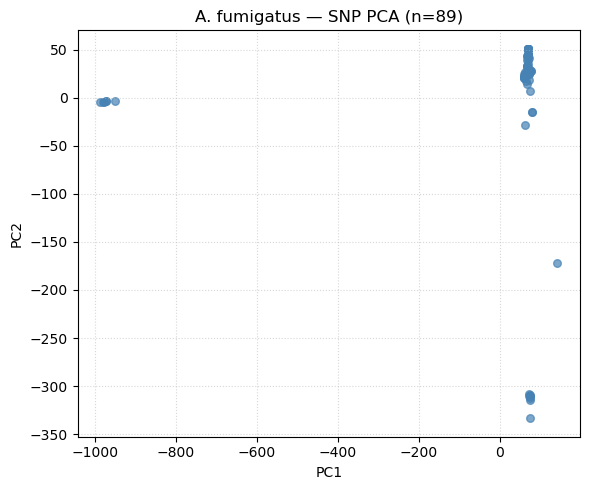

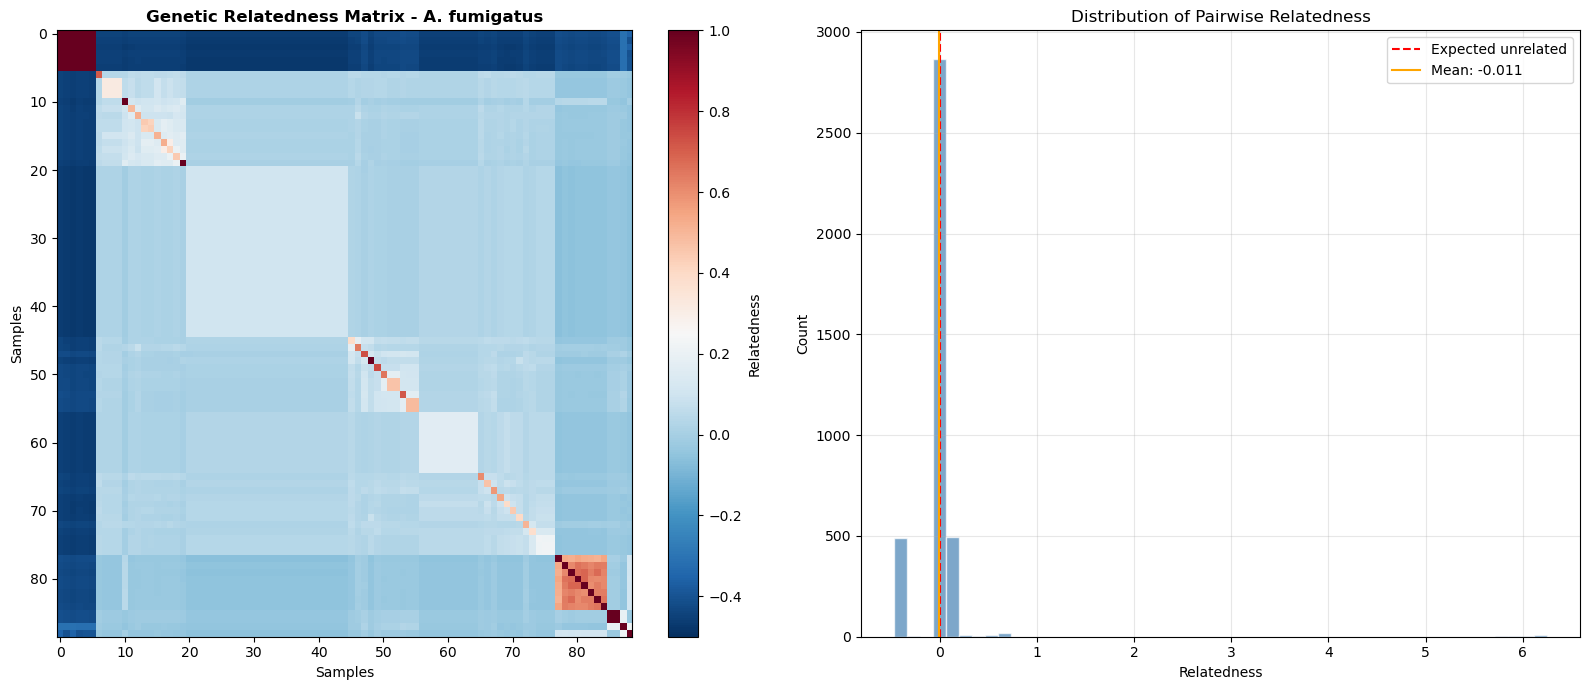


=== flavus ===
Loaded SNP alignment: 71 samples, 964129 SNP sites
  ANI excluded: 1 sample(s) removed before PCA
SNP matrix: 70 samples x 197027 informative SNPs
PCA computed: 10 components
Variance explained: PC1=21.6%, PC2=6.9%
  SNP PCs saved: (70, 11)
GRM computed: 70 x 70 matrix
GRM saved to: /datadrive/Analysis/NB1_Results/flavus/flavus_kinship.tsv


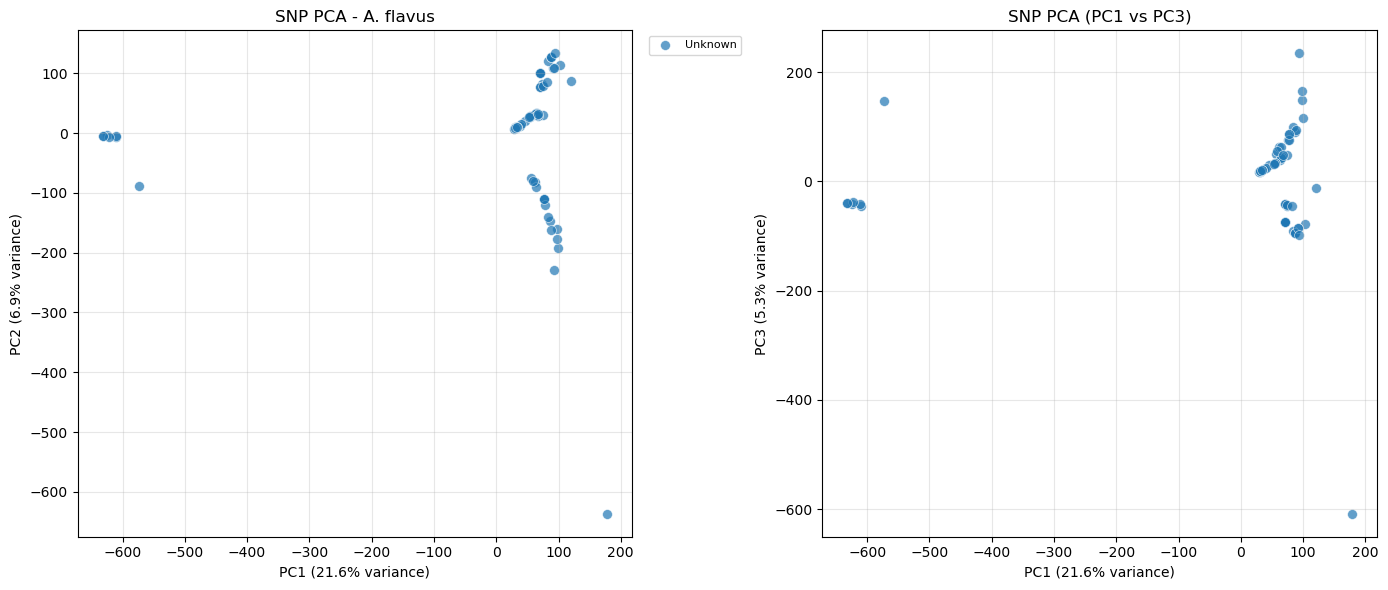

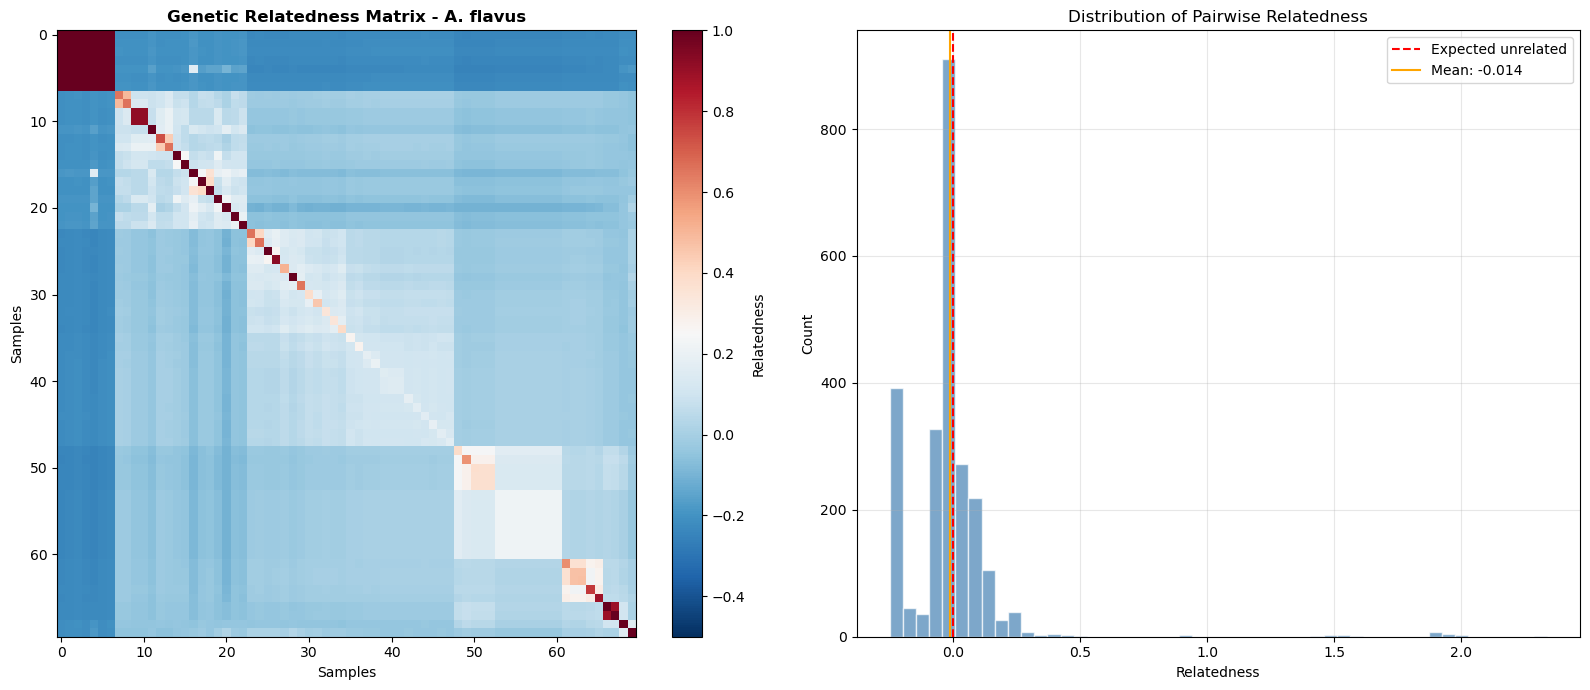

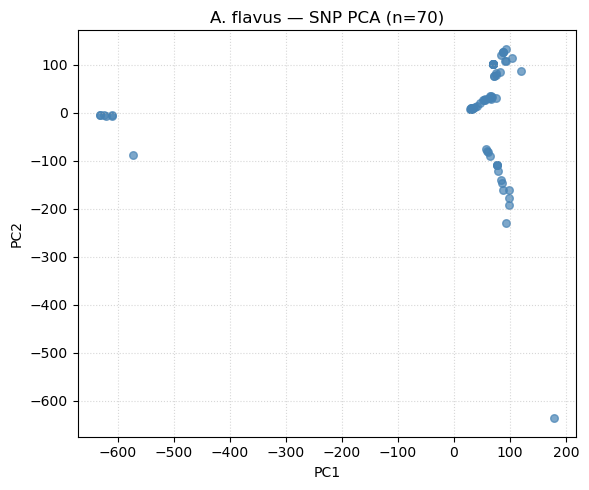

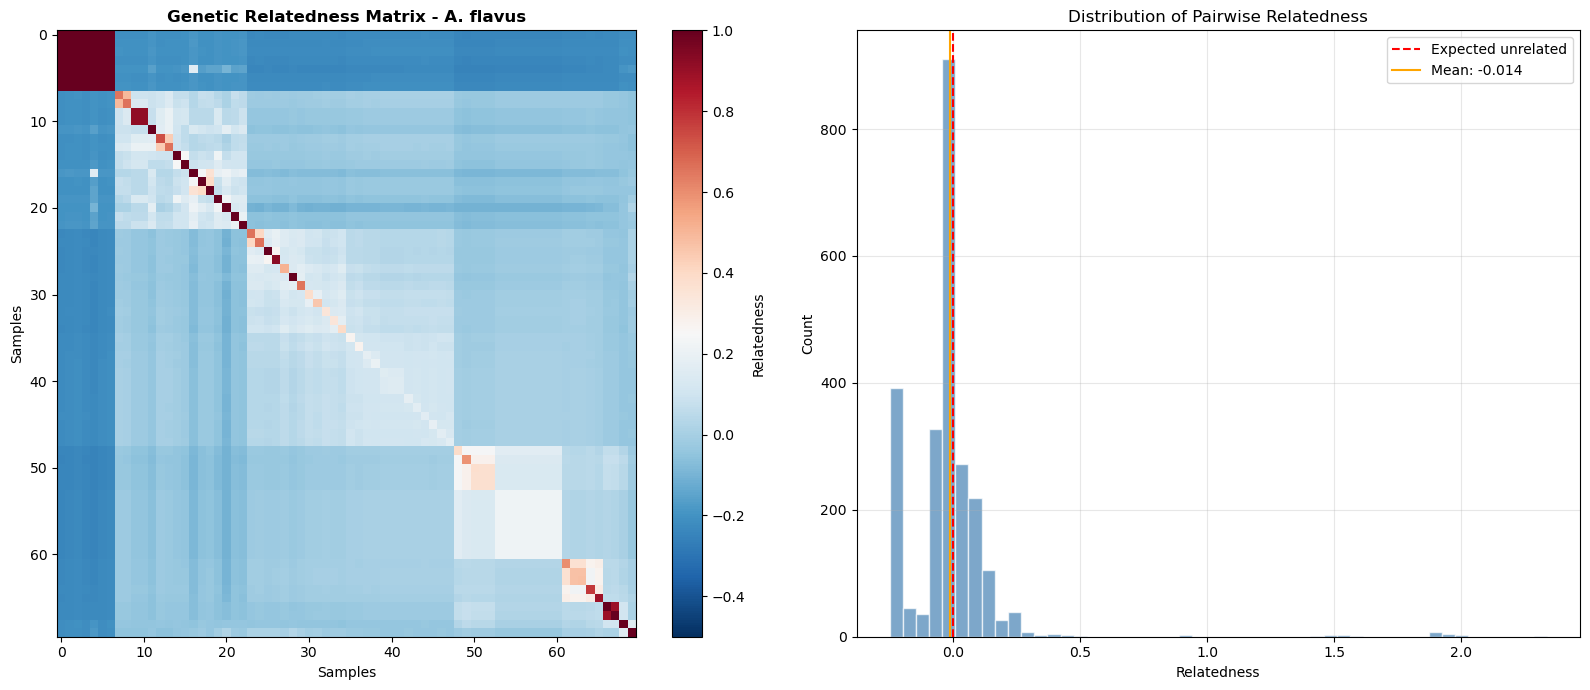


=== niger ===
Loaded SNP alignment: 19 samples, 526864 SNP sites
SNP matrix: 19 samples x 526864 informative SNPs
PCA computed: 10 components
Variance explained: PC1=50.1%, PC2=19.5%
  SNP PCs saved: (19, 11)
GRM computed: 19 x 19 matrix
GRM saved to: /datadrive/Analysis/NB1_Results/niger/niger_kinship.tsv


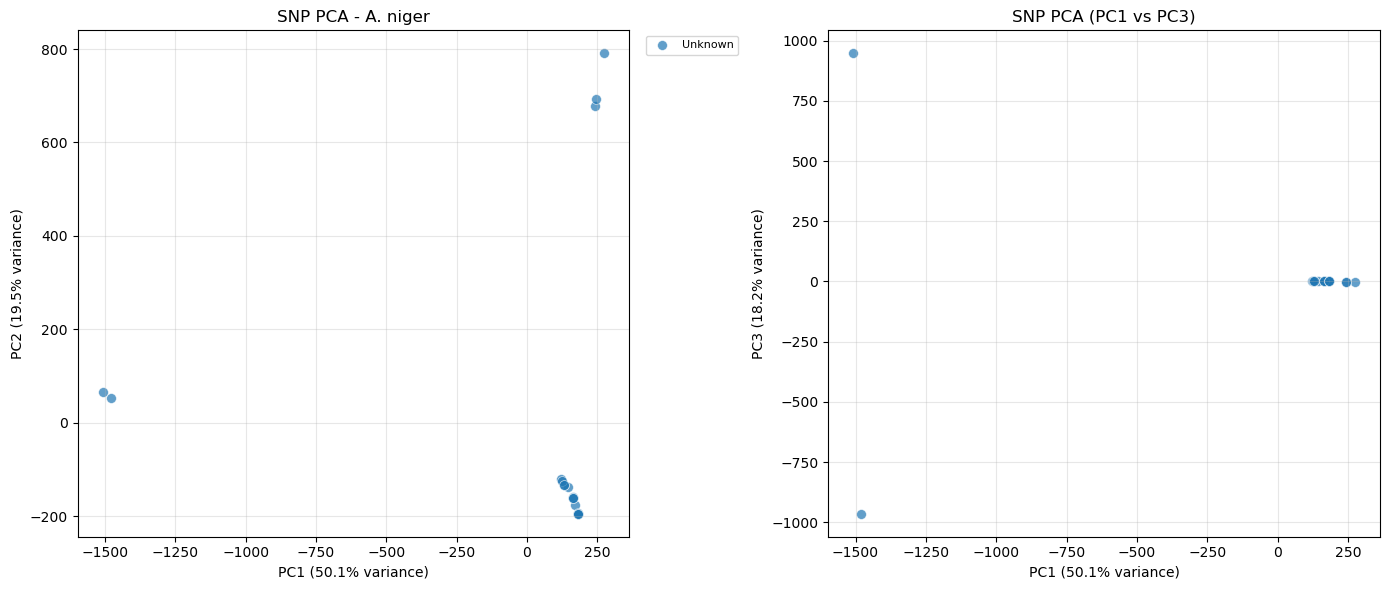

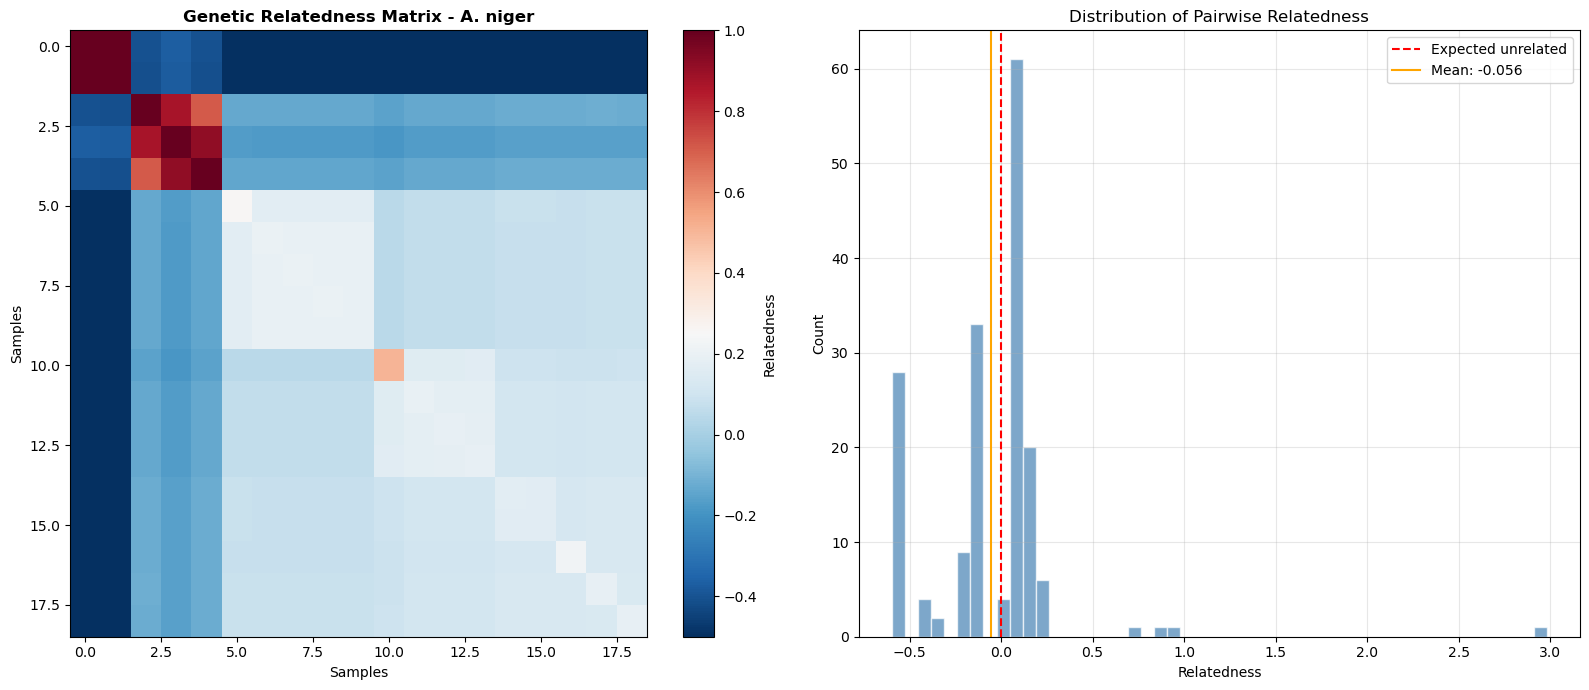

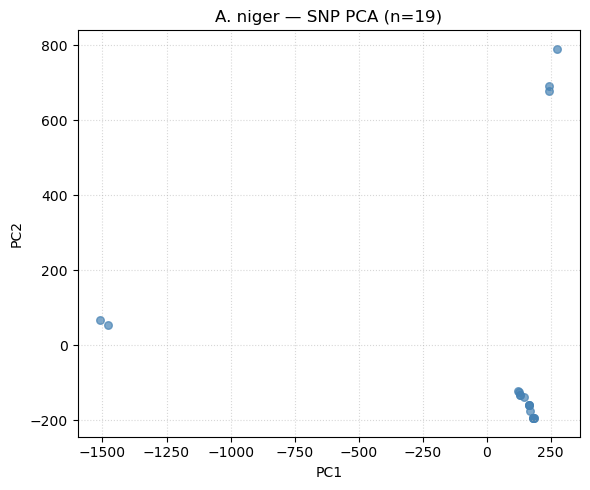

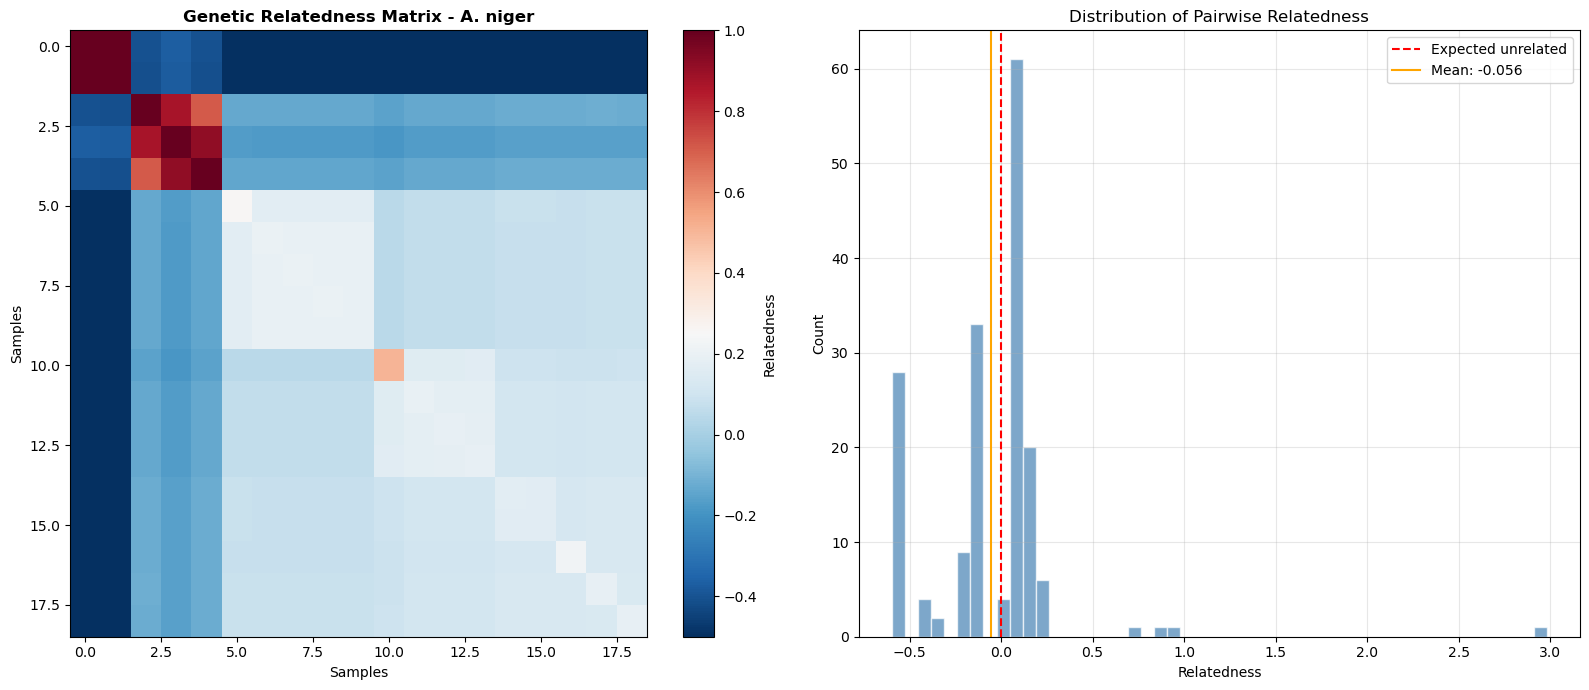


=== oryzae ===
Loaded SNP alignment: 33 samples, 164765 SNP sites
SNP matrix: 33 samples x 164765 informative SNPs
PCA computed: 10 components
Variance explained: PC1=37.2%, PC2=24.7%
  SNP PCs saved: (33, 11)
GRM computed: 33 x 33 matrix
GRM saved to: /datadrive/Analysis/NB1_Results/oryzae/oryzae_kinship.tsv


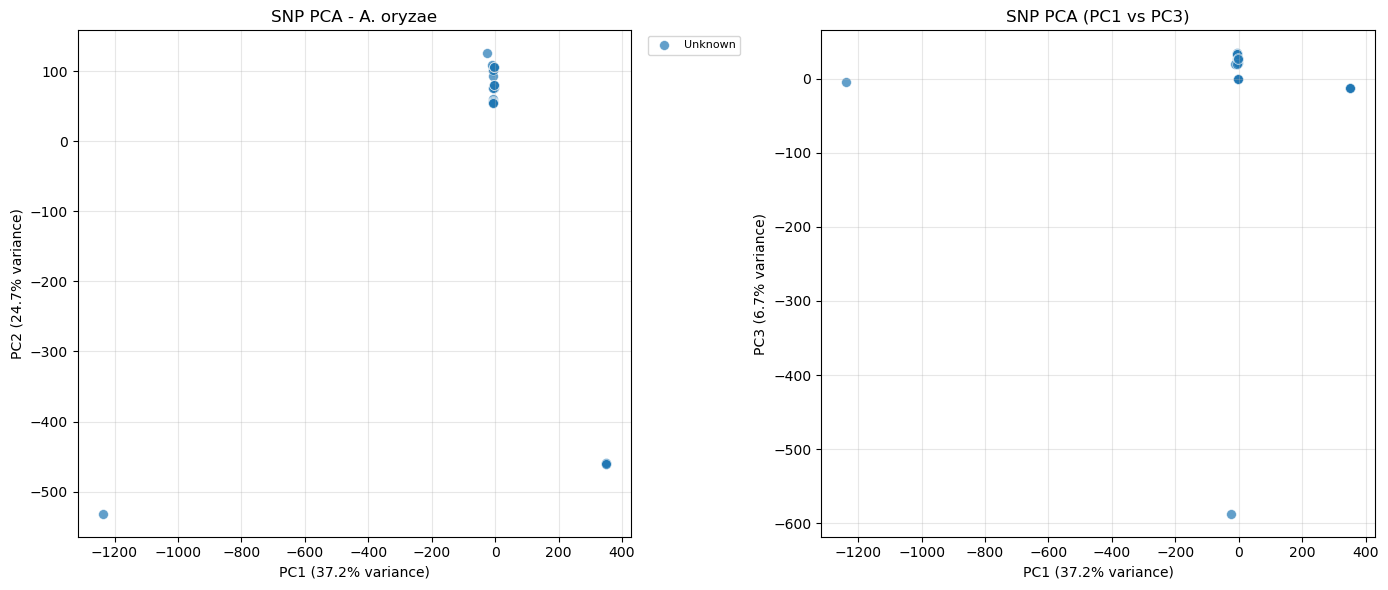

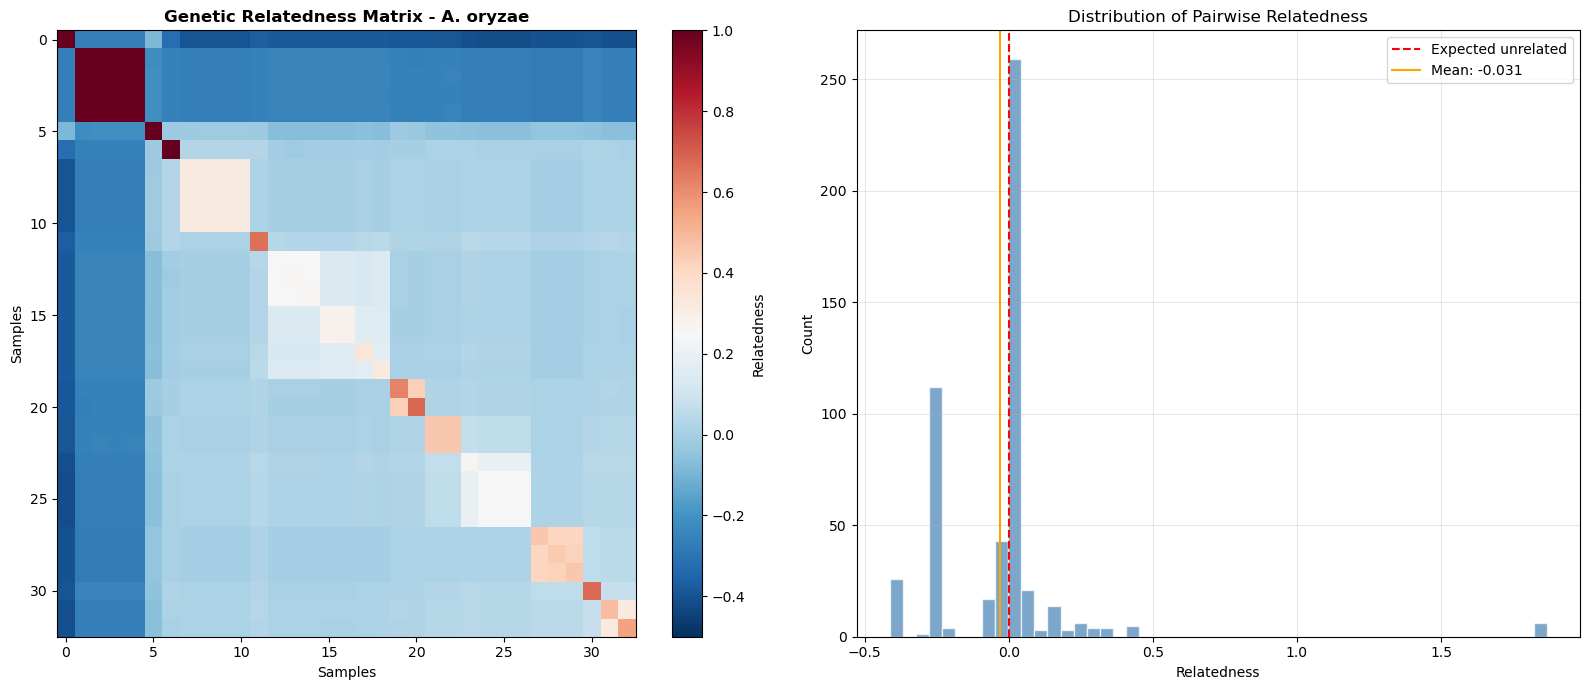

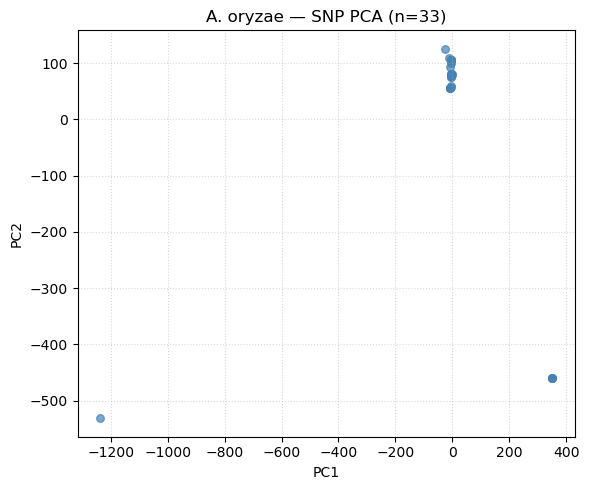

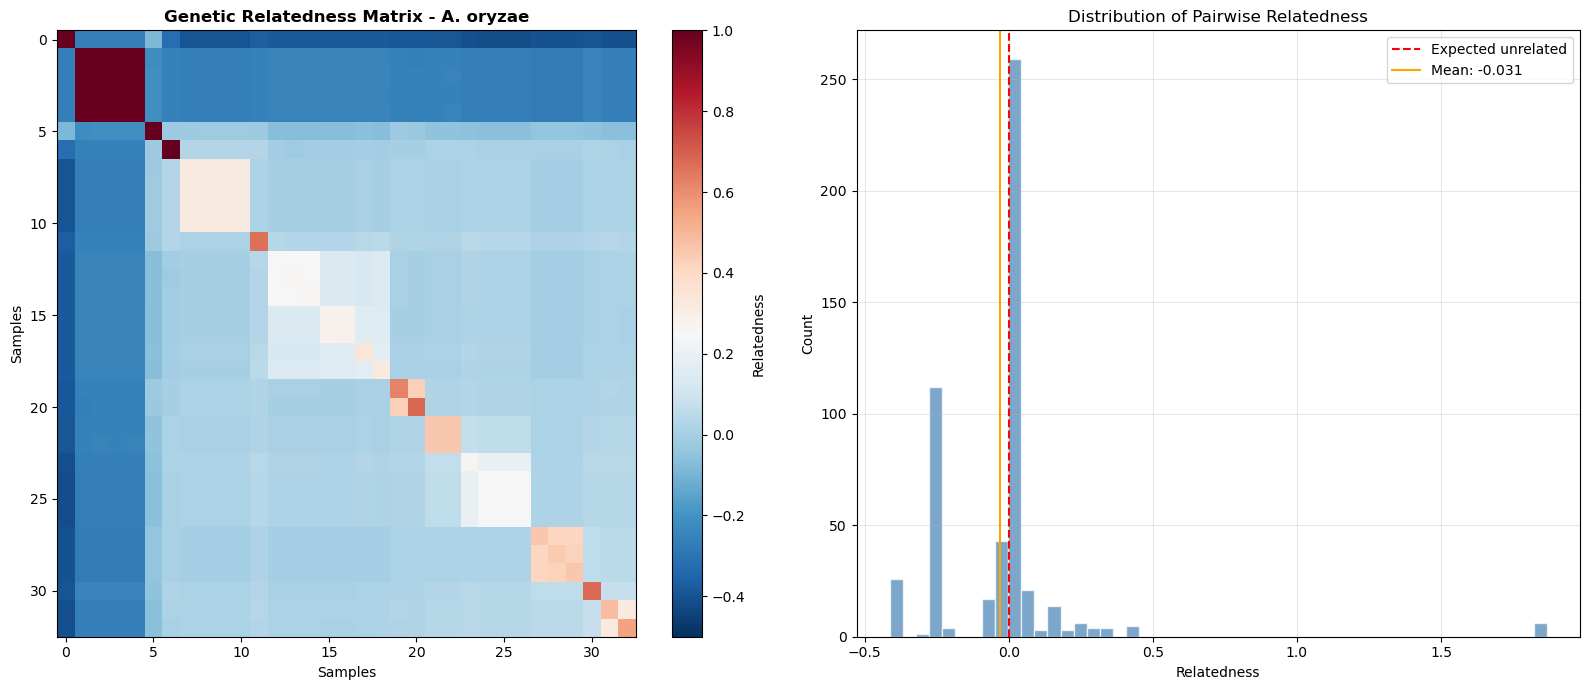

In [12]:
# SNP PCA and GRM/kinship (fpp.run_all_snp_pca_and_grm)
snp_results = fpp.run_all_snp_pca_and_grm(SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE)

---
## Section 8: BGC / GCF Matrix Analysis


=== fumigatus ===
Filtered out 17 MIBiG reference BGCs
Loaded BiG-SCAPE clustering: 3748 BGCs, 74 GCFs, 89 strains
  BiG-SCAPE clustering loaded: 3748 entries
BGC PAV matrix: 89 strains x 3748 BGC regions
  BGC PAV: (89, 3748)
GCF PAV matrix: 89 strains x 74 GCFs
  GCF PAV: (89, 74)
GCF CNV matrix: 89 strains x 74 GCFs
  GCF CNV: (89, 74)


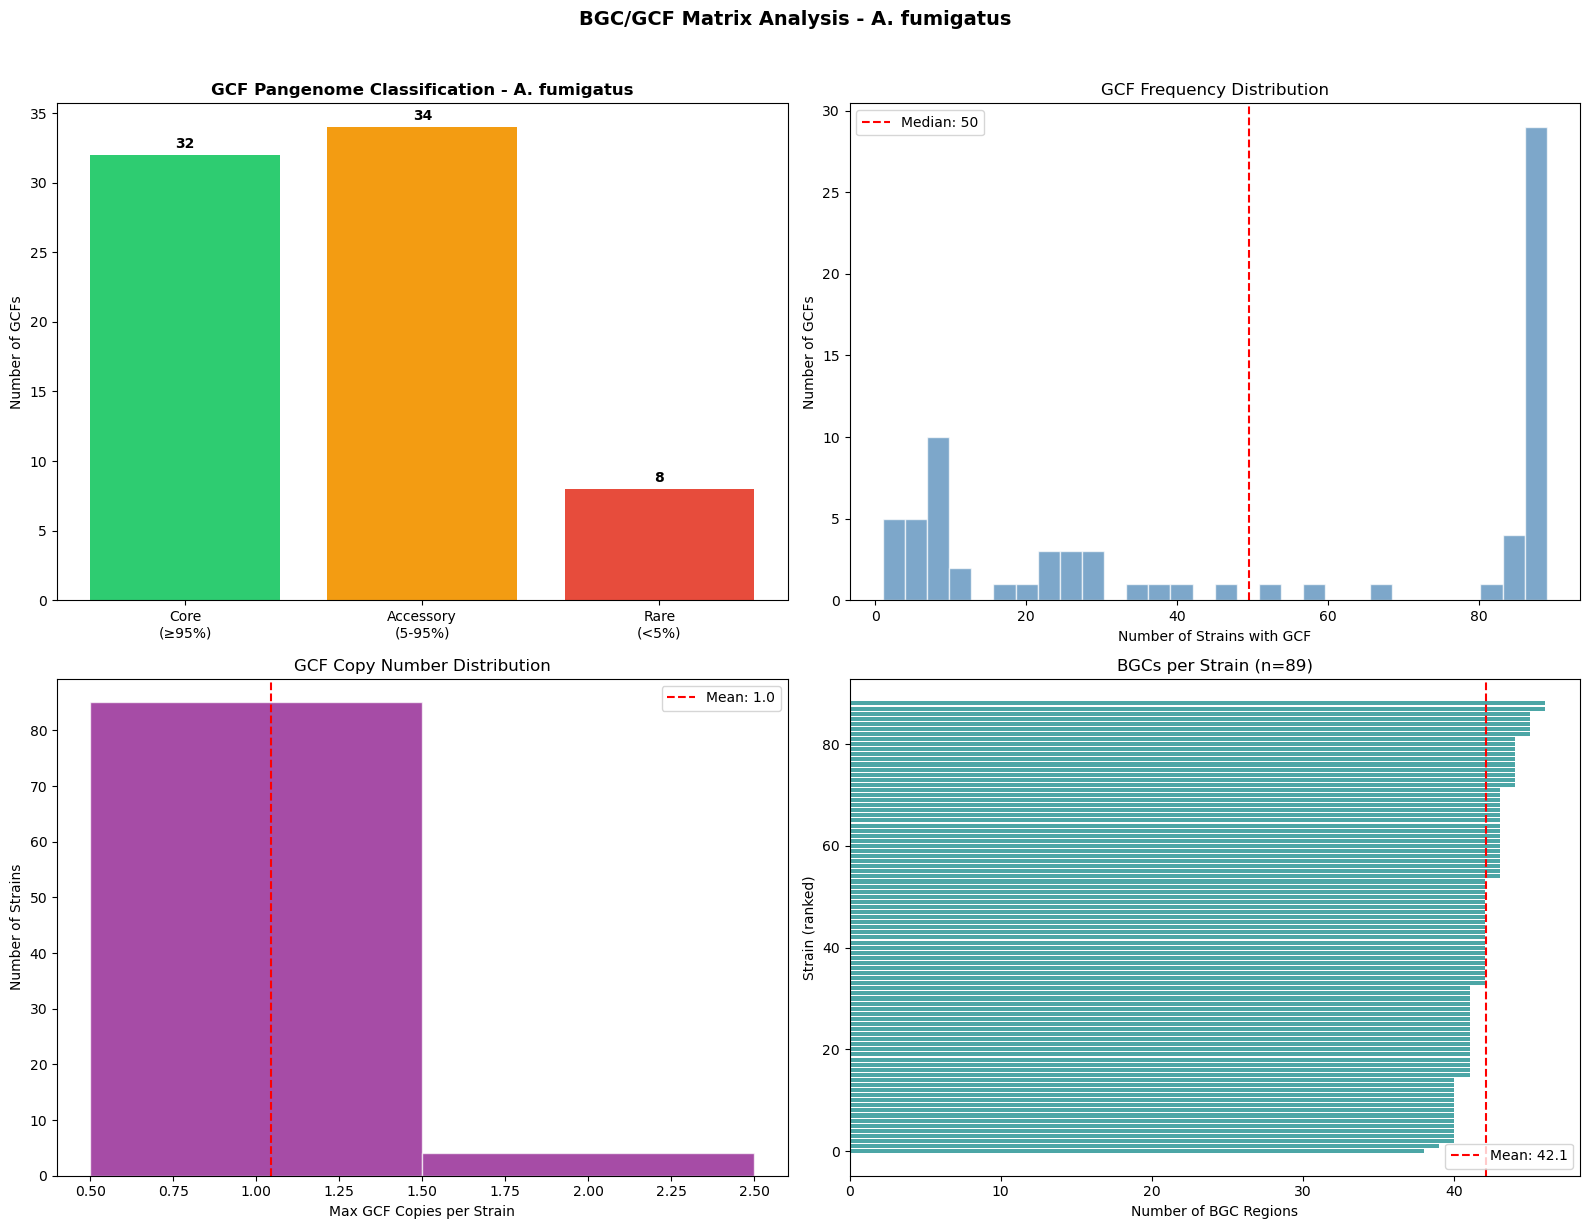


=== flavus ===
Filtered out 38 MIBiG reference BGCs
Loaded BiG-SCAPE clustering: 5768 BGCs, 154 GCFs, 71 strains
  BiG-SCAPE clustering loaded: 5768 entries
BGC PAV matrix: 71 strains x 5768 BGC regions
  BGC PAV: (71, 5768)
GCF PAV matrix: 71 strains x 154 GCFs
  GCF PAV: (71, 154)
GCF CNV matrix: 71 strains x 154 GCFs
  GCF CNV: (71, 154)


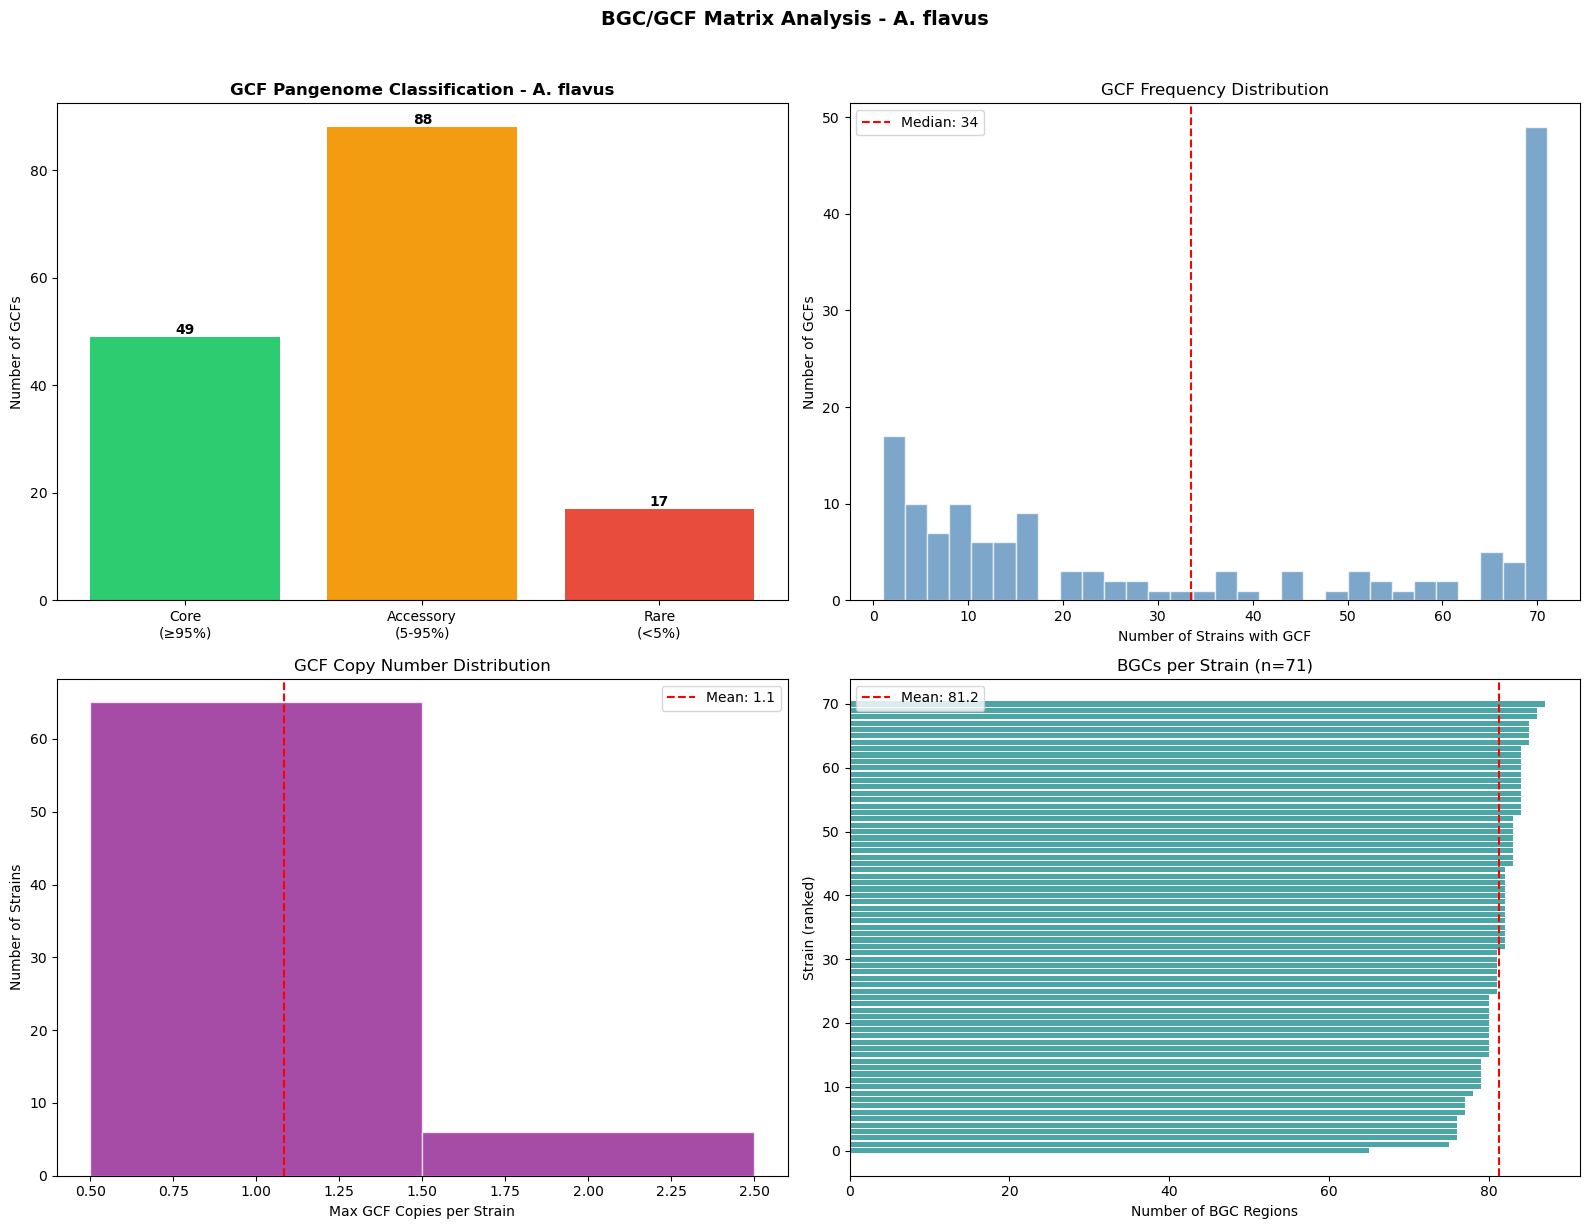


=== niger ===
Filtered out 25 MIBiG reference BGCs
Loaded BiG-SCAPE clustering: 2504 BGCs, 215 GCFs, 30 strains
  BiG-SCAPE clustering loaded: 2504 entries
BGC PAV matrix: 30 strains x 2504 BGC regions
  BGC PAV: (30, 2504)
GCF PAV matrix: 30 strains x 215 GCFs
  GCF PAV: (30, 215)
GCF CNV matrix: 30 strains x 215 GCFs
  GCF CNV: (30, 215)


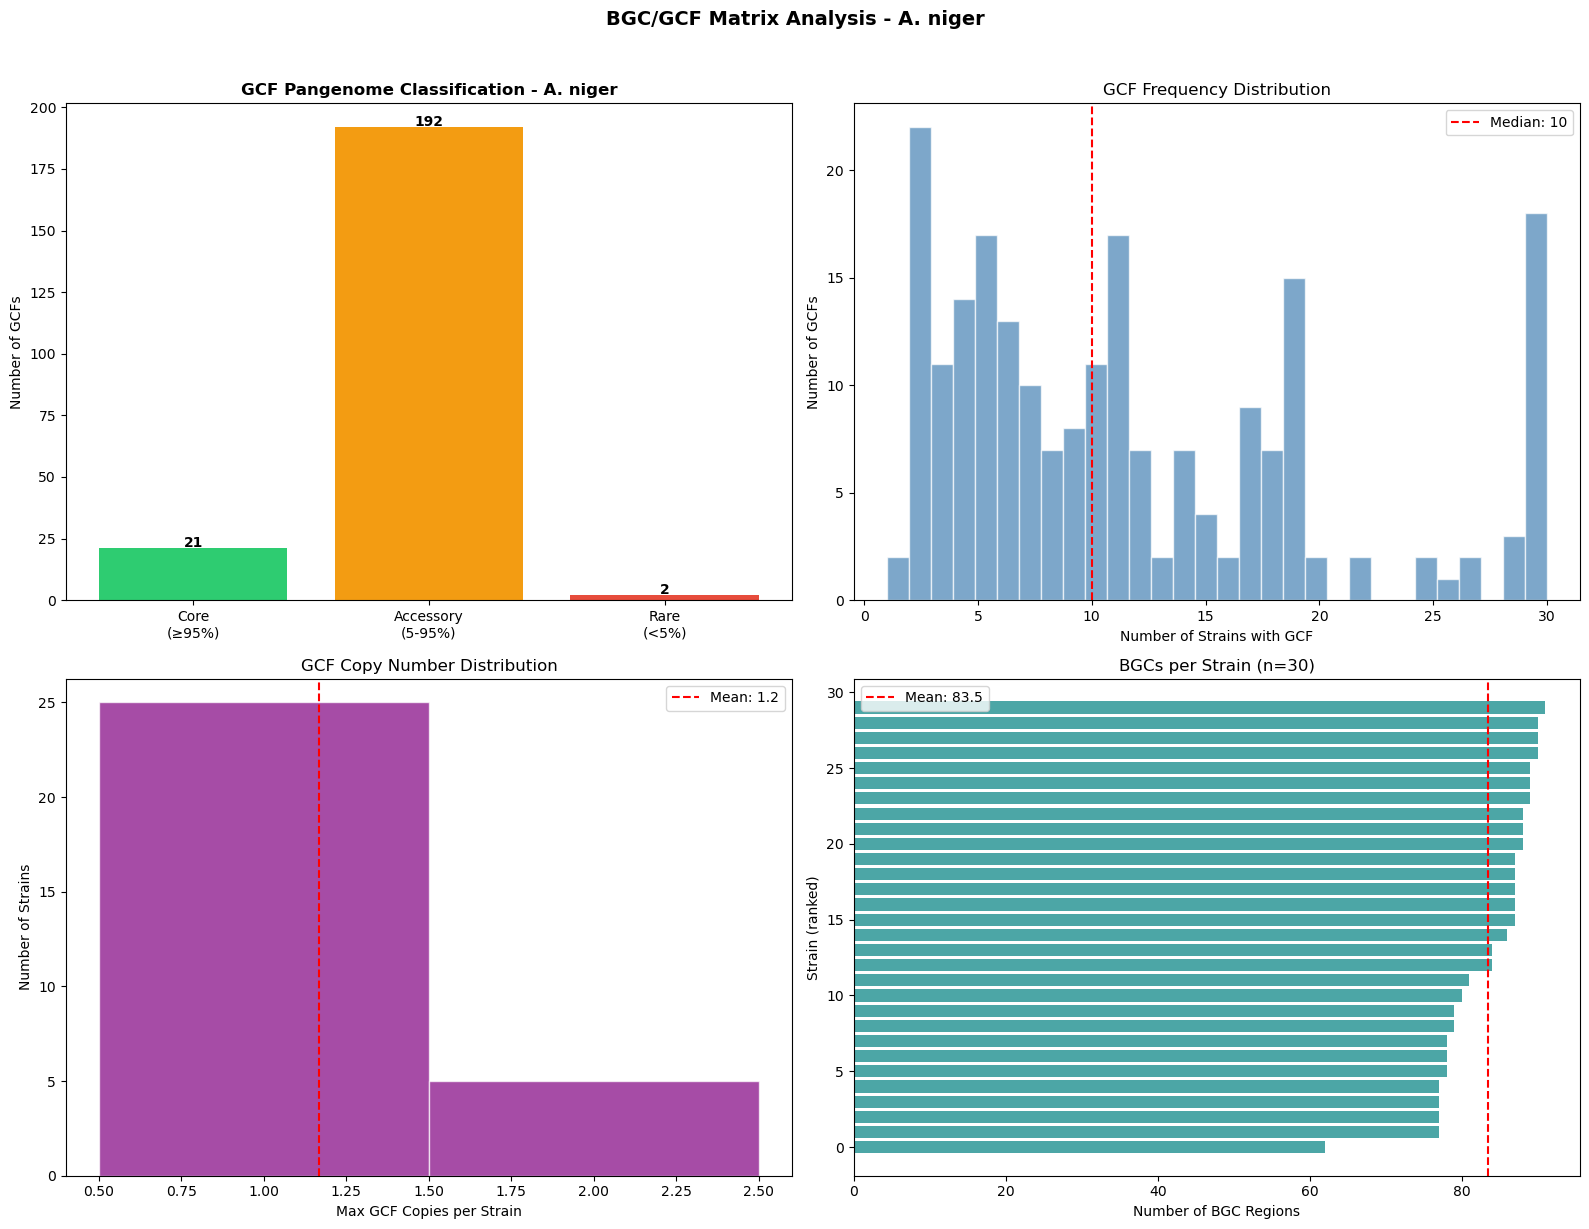


=== oryzae ===
Filtered out 32 MIBiG reference BGCs
Loaded BiG-SCAPE clustering: 2702 BGCs, 129 GCFs, 33 strains
  BiG-SCAPE clustering loaded: 2702 entries
BGC PAV matrix: 33 strains x 2702 BGC regions
  BGC PAV: (33, 2702)
GCF PAV matrix: 33 strains x 129 GCFs
  GCF PAV: (33, 129)
GCF CNV matrix: 33 strains x 129 GCFs
  GCF CNV: (33, 129)


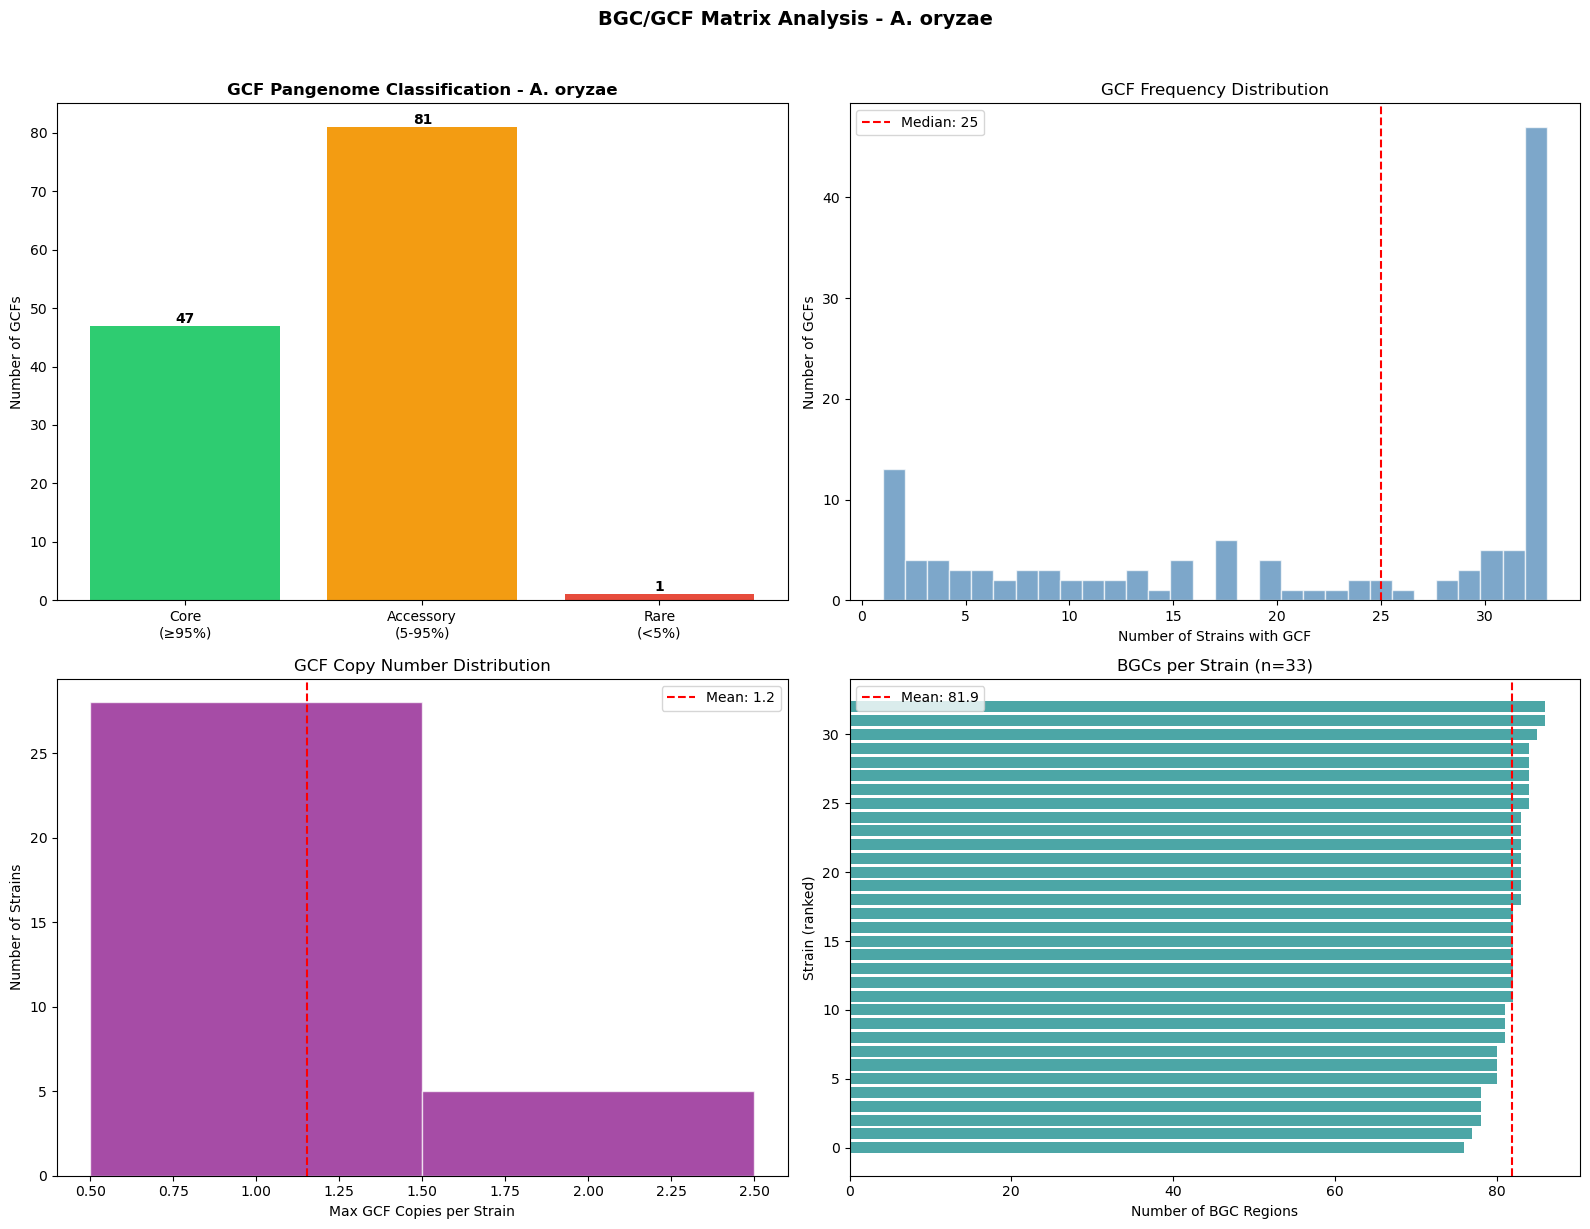

In [13]:
# BGC/GCF matrix analysis (fpp.run_all_bgc_gcf)
bgc_results = fpp.run_all_bgc_gcf(SPECIES_LIST, SPECIES_ROOT, RESULTS_BASE)

---
## Summary

All pangenome architecture outputs have been written to `NB1_Results/{species}/`:

| File | Description |
|------|-------------|
| `{species}_pav.tsv` | Orthogroup presence/absence matrix |
| `{species}_cnv.tsv` | Orthogroup copy-number matrix |
| `{species}_og_consensus.tsv` | OG consensus annotations with pangenome class |
| `{species}_functional_*_counts.tsv` | Functional count matrices per annotation layer |
| `{species}_snp_pcs.tsv` | SNP principal components |
| `{species}_kinship.tsv` | Genomic relationship matrix |
| `{species}_bgc_pav.tsv` | BGC presence/absence matrix |
| `{species}_gcf_pav.tsv` | GCF presence/absence matrix |
| `{species}_gcf_cnv.tsv` | GCF copy-number matrix |

These matrices feed into downstream notebooks (NB2--NB4) for GWAS, phylogenomics, and SM analysis.